## Domain Overview: 1D Offshore Domain & EEZ Interface


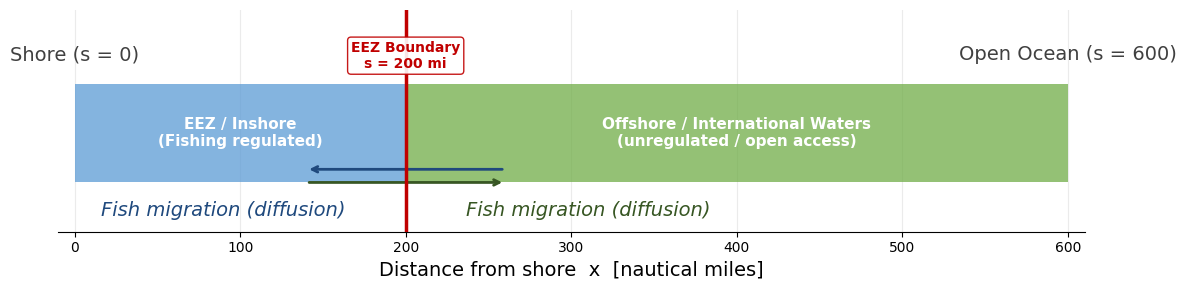

In [289]:
import numpy as np
import matplotlib.pyplot as plt

L = 600.0
s_eez = 200.0

fig, ax = plt.subplots(figsize=(12, 3.0))
fig.patch.set_facecolor('white')

ax.barh(0, s_eez,     height=0.6, left=0,     color='#5B9BD5', alpha=0.75, zorder=2)
ax.barh(0, L - s_eez, height=0.6, left=s_eez, color='#70AD47', alpha=0.75, zorder=2)

ax.text(s_eez / 2, 0, 'EEZ / Inshore\n(Fishing regulated)',
        ha='center', va='center', fontsize=11, fontweight='bold', color='white', zorder=3)
ax.text(s_eez + (L - s_eez) / 2, 0, 'Offshore / International Waters\n(unregulated / open access)',
        ha='center', va='center', fontsize=11, fontweight='bold', color='white', zorder=3)

ax.axvline(s_eez, color='#C00000', linewidth=2.5, zorder=4)
ax.text(s_eez, 0.38, 'EEZ Boundary\ns = 200 mi',
        ha='center', va='bottom', fontsize=10, color='#C00000', fontweight='bold', zorder=5,
        bbox=dict(boxstyle='round,pad=0.25', fc='white', ec='#C00000', alpha=0.9))

# Offshore -> Inshore (fish migrating inshore across boundary, upper lane)
ax.annotate('', xy=(s_eez - 60, -0.22), xytext=(s_eez + 60, -0.22),
            arrowprops=dict(arrowstyle='->', color='#1F497D', lw=2.0))
# Inshore -> Offshore (fish migrating offshore across boundary, lower lane)
ax.annotate('', xy=(s_eez + 60, -0.30), xytext=(s_eez - 60, -0.30),
            arrowprops=dict(arrowstyle='->', color='#375623', lw=2.0))
ax.text(s_eez - 110, -0.41, 'Fish migration (diffusion)',
        ha='center', va='top', fontsize=14, color='#1F497D', style='italic')
ax.text(s_eez + 110, -0.41, 'Fish migration (diffusion)',
        ha='center', va='top', fontsize=14, color='#375623', style='italic')

ax.text(0, 0.42, 'Shore (s = 0)',        ha='center', va='bottom', fontsize=14, color='#404040')
ax.text(L, 0.42, 'Open Ocean (s = 600)', ha='center', va='bottom', fontsize=14, color='#404040')

ax.set_xlim(-10, L + 10)
ax.set_ylim(-0.6, 0.75)
ax.set_xticks([0, 100, 200, 300, 400, 500, 600])
ax.set_xlabel('Distance from shore  x  [nautical miles]', fontsize=14)
ax.set_yticks([])
ax.spines[['left', 'right', 'top']].set_visible(False)
ax.grid(axis='x', alpha=0.25, zorder=1)

plt.tight_layout()
plt.show()


# 3A Ã¢â‚¬â€ Pure Diffusion Sanity Check (Migration Only)

**Purpose:** validate the spatial finite-difference discretisation and Neumann (no-flux) boundary conditions *before* adding logistic growth or fishing.

Using the substitution $x = u/K$, $\xi = s/L$, $\tau = r_{\rm ref}\,t$ (with reference rate $r_{\rm ref} = 0.5$), the dimensional diffusion PDE $\partial u/\partial t = D\,\partial^2 u/\partial s^2$ becomes the **dimensionless diffusion PDE** on $\xi \in [0,1]$:

$$
\frac{\partial x}{\partial \tau} = \delta\,\frac{\partial^2 x}{\partial \xi^2}, \qquad \delta = \frac{D}{r_{\rm ref}\,L^2}
$$

with no-flux boundaries:

$$
\frac{\partial x}{\partial \xi}(0,\tau) = 0, \qquad \frac{\partial x}{\partial \xi}(1,\tau) = 0
$$

*(Note: using the growth timescale $\tau = r_{\rm ref}\,t$ keeps the timescale consistent with 3B. The alternative diffusion timescale $\tilde\tau = (D/L^2)\,t$ gives $\partial x/\partial\tilde\tau = \partial^2 x/\partial\xi^2$ with $\delta$ absorbed into 1, but we prefer consistency.)*

**Expected behaviour:**
- The initial Gaussian bump (centred at $\xi = 0.25$) spreads and flattens over time.
- Total mass $M(\tau) = \int_0^1 x\,d\xi$ is conserved (no-flux + no reaction).


ÃŽÂ´ = D/(r_refÃ‚Â·LÃ‚Â²) = 5.556e-05,   Ãâ€ž_end = 100.0


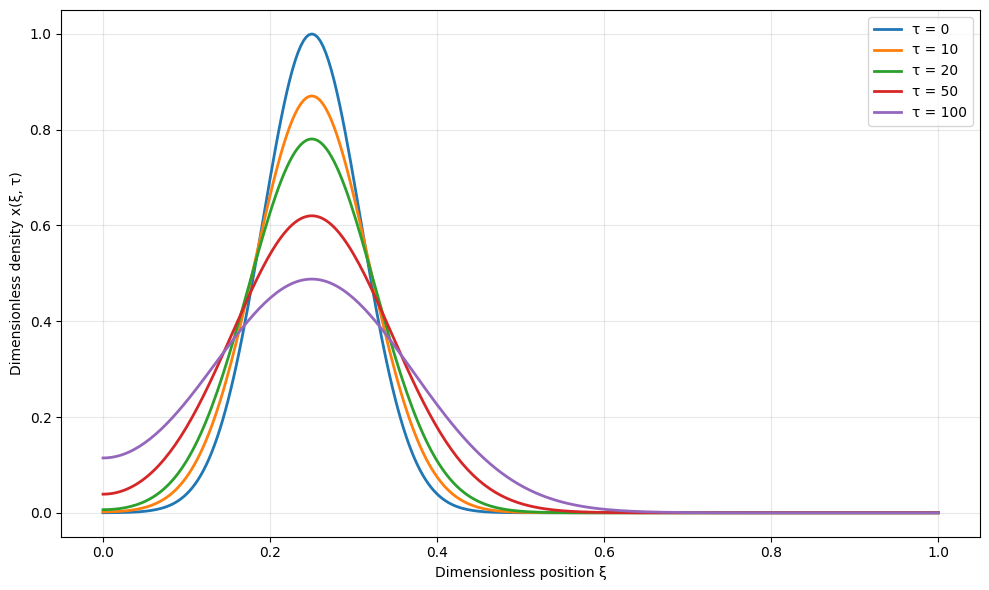

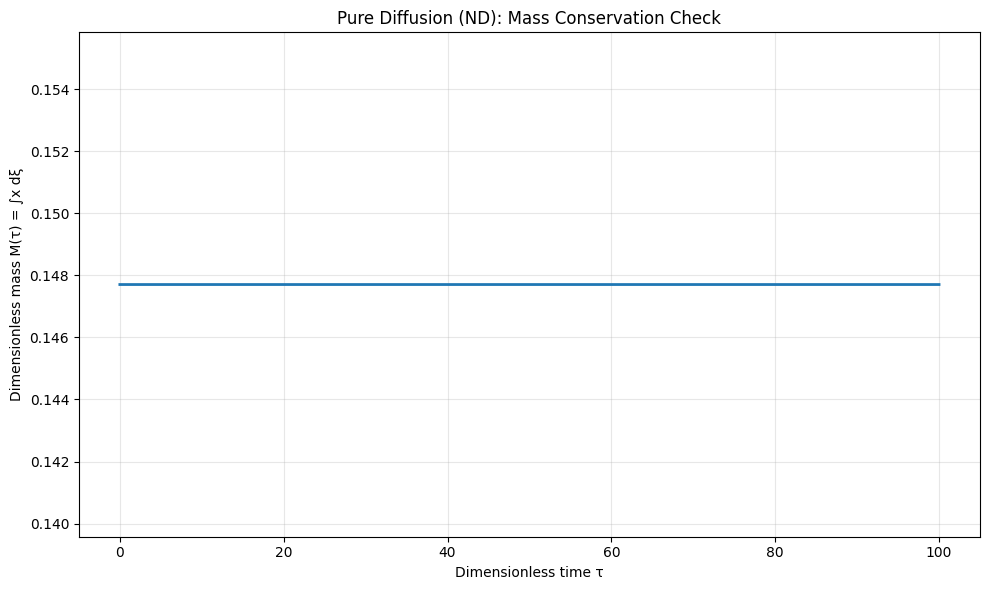

In [290]:
import numpy as np
from matplotlib import pyplot as plt

from pde_solver import laplacian_neumann

# Ã¢â€â‚¬Ã¢â€â‚¬ Dimensional reference parameters Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬
r_ref: float = 0.5      # reference growth rate (for Ãâ€ž = rÃ‚Â·t timescale)
L_ref: float = 600.0    # domain length
D_ref: float = 10.0     # diffusion coefficient
T_end_dim: float = 200.0 # end time (dimensional)

# Ã¢â€â‚¬Ã¢â€â‚¬ ND parameters Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬
N: int = 301
delta: float = D_ref / (r_ref * L_ref**2)   # ÃŽÂ´ = D/(rÃ‚Â·LÃ‚Â²) Ã¢â€°Ë† 5.556e-05
dxi: float = 1.0 / (N - 1)                   # ÃŽâ€ÃŽÂ¾
tau_end: float = r_ref * T_end_dim            # Ãâ€ž_end = 100.0
xi = np.linspace(0.0, 1.0, N)               # ÃŽÂ¾ Ã¢Ë†Ë† [0,1]

print(f"ÃŽÂ´ = D/(r_refÃ‚Â·LÃ‚Â²) = {delta:.3e},   Ãâ€ž_end = {tau_end:.1f}")

# Ã¢â€â‚¬Ã¢â€â‚¬ Stability: dÃâ€ž Ã¢â€°Â¤ dÃŽÂ¾Ã‚Â²/(2ÃŽÂ´) Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬
dtau_max = dxi**2 / (2.0 * delta)
dtau = 0.45 * dtau_max
nt = int(np.ceil(tau_end / dtau))
dtau = tau_end / nt     # adjust to land exactly on Ãâ€ž_end

# Ã¢â€â‚¬Ã¢â€â‚¬ Initial condition: Gaussian at ÃŽÂ¾_peak=0.25, ÃÆ’_ÃŽÂ¾=1/12 Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬
xi_peak: float = 150.0 / L_ref             # = 0.25
sigma_xi: float = 50.0 / L_ref            # Ã¢â€°Ë† 0.0833
x = np.exp(-((xi - xi_peak) / sigma_xi)**2)

# Ã¢â€â‚¬Ã¢â€â‚¬ Time integration (explicit Euler) Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬
# PDE: dx/dÃâ€ž = ÃŽÂ´ Ã‚Â· dÃ‚Â²x/dÃŽÂ¾Ã‚Â²
snapshot_times = {0.0, 10, 20, 50.0, 100.0}   # Ãâ€ž snapshots
snapshots: dict[float, np.ndarray] = {0.0: x.copy()}

mass_history = np.empty(nt + 1)
time_history = np.empty(nt + 1)
mass_history[0] = np.trapezoid(x, xi)
time_history[0] = 0.0

tau = 0.0
for n in range(1, nt + 1):
    x = x + dtau * delta * laplacian_neumann(x, dxi)
    tau = n * dtau
    mass_history[n] = np.trapezoid(x, xi)
    time_history[n] = tau
    for ts in list(snapshot_times):
        if abs(tau - ts) < 0.5 * dtau:
            snapshots[ts] = x.copy()
            snapshot_times.discard(ts)

# Ã¢â€â‚¬Ã¢â€â‚¬ Density snapshots Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬
fig_a, ax_a = plt.subplots(figsize=(10, 6))
for t_snap in sorted(snapshots):
    ax_a.plot(xi, snapshots[t_snap], linewidth=2.0, label=f"\u03c4 = {t_snap:g}")
# ax_a.set_title("Pure Diffusion (ND): Density Snapshots")
ax_a.set_xlabel("Dimensionless position \u03be")
ax_a.set_ylabel("Dimensionless density x(\u03be, \u03c4)")
ax_a.grid(True, alpha=0.3)
ax_a.legend()
fig_a.tight_layout()
plt.show()

# Ã¢â€â‚¬Ã¢â€â‚¬ Mass conservation check Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬
fig_b, ax_b = plt.subplots(figsize=(10, 6))
ax_b.plot(time_history, mass_history, linewidth=2.0)
ax_b.set_title("Pure Diffusion (ND): Mass Conservation Check")
ax_b.set_xlabel("Dimensionless time \u03c4")
ax_b.set_ylabel("Dimensionless mass M(\u03c4) = \u222bx d\u03be")
ax_b.grid(True, alpha=0.3)
fig_b.tight_layout()
plt.show()


# 3B Ã¢â‚¬â€ ReactionÃ¢â‚¬â€œDiffusion: Logistic Growth + Migration (No Fishing)

Using $x = u/K$, $\xi = s/L$, $\tau = rt$, $\delta = D/(rL^2)$, the dimensional PDE

$$
\frac{\partial u}{\partial t} = r\,u\!\left(1 - \frac{u}{K}\right) + D\,\frac{\partial^2 u}{\partial s^2}
$$

becomes the **dimensionless reactionÃ¢â‚¬â€œdiffusion PDE** on $\xi \in [0,1]$:

$$
\frac{\partial x}{\partial \tau} = x(1 - x) + \delta\,\frac{\partial^2 x}{\partial \xi^2}, \qquad \frac{\partial x}{\partial \xi}(0,\tau) = \frac{\partial x}{\partial \xi}(1,\tau) = 0
$$

The single parameter $\delta = D/(rL^2)$ controls the ratio of diffusion to growth. Here $\delta \approx 5.6 \times 10^{-5}$, so growth dominates at short times and spatial gradients persist.

**Two sub-experiments:**
- **(A) Non-uniform IC** Ã¢â‚¬â€ Gaussian bump at $\xi=0.25$: observe growth filling the domain toward $x^*=1$ while diffusion smooths the profile.
- **(B) Uniform IC validation** Ã¢â‚¬â€ spatially constant $x_0 = 0.2$: PDE reduces to the ND logistic ODE $d\tilde{x}/d\tau = \tilde{x}(1-\tilde{x})$. Overlay the analytic ND solution to confirm.


ÃŽÂ´ = D/(rÃ‚Â·LÃ‚Â²) = 5.556e-05,   Ãâ€ž_end = 30.0


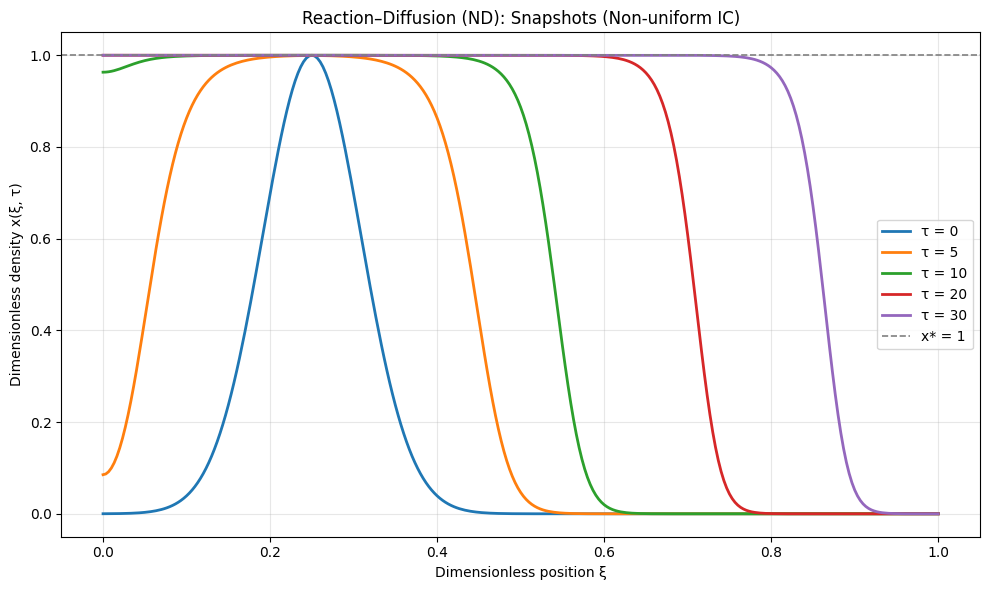

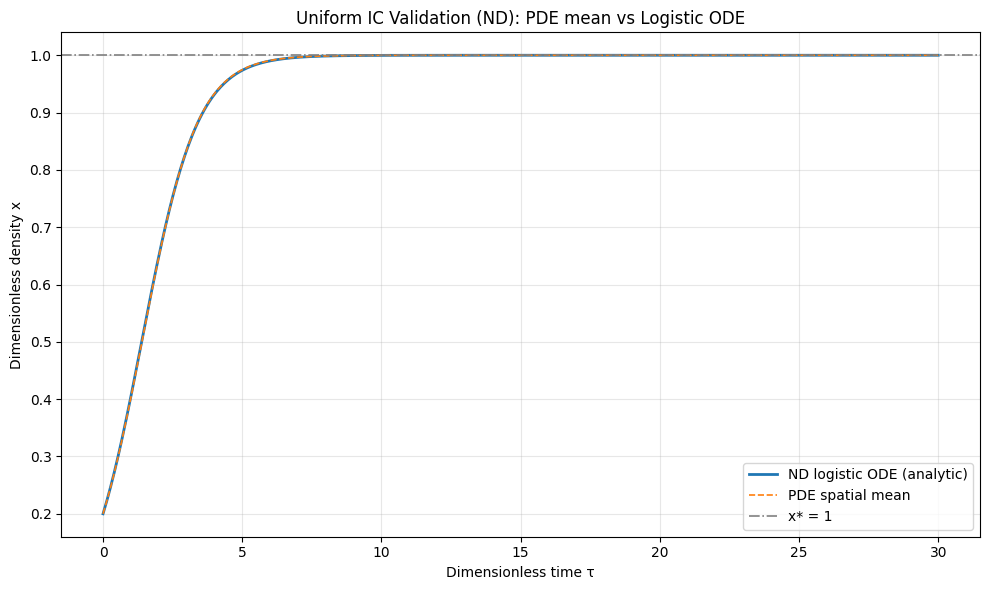

In [291]:
import numpy as np
from matplotlib import pyplot as plt

from pde_solver import laplacian_neumann
from ode_models import logistic_analytic

# Ã¢â€â‚¬Ã¢â€â‚¬ Dimensional reference parameters Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬
L_rd: float = 600.0
N_rd: int = 301
D_rd: float = 10.0
r_rd: float = 0.5
T_end_rd_dim: float = 60.0

# Ã¢â€â‚¬Ã¢â€â‚¬ ND parameters Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬
# ÃŽÂ´ = D/(rÃ‚Â·LÃ‚Â²),  ÃŽÂ¾ Ã¢Ë†Ë† [0,1],  Ãâ€ž = rÃ‚Â·t
delta: float = D_rd / (r_rd * L_rd**2)      # Ã¢â€°Ë† 5.556e-05
dxi_rd: float = 1.0 / (N_rd - 1)
tau_end_rd: float = r_rd * T_end_rd_dim      # = 30.0
xi_rd = np.linspace(0.0, 1.0, N_rd)

print(f"ÃŽÂ´ = D/(rÃ‚Â·LÃ‚Â²) = {delta:.3e},   Ãâ€ž_end = {tau_end_rd:.1f}")

# Stability: dÃâ€ž Ã¢â€°Â¤ dÃŽÂ¾Ã‚Â²/(2ÃŽÂ´)
dtau_rd = 0.45 * dxi_rd**2 / (2.0 * delta)
nt_rd = int(np.ceil(tau_end_rd / dtau_rd))
dtau_rd = tau_end_rd / nt_rd   # adjust to land exactly on Ãâ€ž_end

# =====================================================================
# Part A Ã¢â‚¬â€ Non-uniform IC (Gaussian bump at ÃŽÂ¾=0.25)
# =====================================================================
xi_peak_rd: float = 150.0 / L_rd    # = 0.25
sigma_xi_rd: float = 50.0 / L_rd   # Ã¢â€°Ë† 0.0833
x_a = np.exp(-((xi_rd - xi_peak_rd) / sigma_xi_rd)**2)

snapshot_times_a = {0.0, 5.0, 10.0, 20.0, 30.0}   # Ãâ€ž values
snapshots_a: dict[float, np.ndarray] = {0.0: x_a.copy()}

tau_a = 0.0
for n in range(1, nt_rd + 1):
    lap = laplacian_neumann(x_a, dxi_rd)
    x_a = x_a + dtau_rd * (x_a * (1.0 - x_a) + delta * lap)
    tau_a = n * dtau_rd
    for ts in list(snapshot_times_a):
        if abs(tau_a - ts) < 0.5 * dtau_rd:
            snapshots_a[ts] = x_a.copy()
            snapshot_times_a.discard(ts)

# Ã¢â€â‚¬Ã¢â€â‚¬ Plot: Non-uniform IC snapshots Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬
fig_a, ax_a = plt.subplots(figsize=(10, 6))
for t_snap in sorted(snapshots_a):
    ax_a.plot(xi_rd, snapshots_a[t_snap], linewidth=2.0, label=f"\u03c4 = {t_snap:g}")
ax_a.axhline(1.0, color="gray", linestyle="--", linewidth=1.2, label="x* = 1")
ax_a.set_title("Reaction\u2013Diffusion (ND): Snapshots (Non-uniform IC)")
ax_a.set_xlabel("Dimensionless position \u03be")
ax_a.set_ylabel("Dimensionless density x(\u03be, \u03c4)")
ax_a.grid(True, alpha=0.3)
ax_a.legend()
fig_a.tight_layout()
plt.show()

# =====================================================================
# Part B Ã¢â‚¬â€ Uniform IC validation (xÃ¢â€šâ‚¬ = 0.2)
# =====================================================================
x0_uniform: float = 0.2    # xÃŒÆ’Ã¢â€šâ‚¬ = uÃ¢â€šâ‚¬/K = 0.2Ã‚Â·K/K
x_b = x0_uniform * np.ones(N_rd)

mean_history = np.empty(nt_rd + 1)
max_dev_history = np.empty(nt_rd + 1)
time_history_tau = np.empty(nt_rd + 1)

mean_history[0] = x_b.mean()
max_dev_history[0] = x_b.max() - x_b.min()
time_history_tau[0] = 0.0

for n in range(1, nt_rd + 1):
    lap = laplacian_neumann(x_b, dxi_rd)
    x_b = x_b + dtau_rd * (x_b * (1.0 - x_b) + delta * lap)
    time_history_tau[n] = n * dtau_rd
    mean_history[n] = x_b.mean()
    max_dev_history[n] = x_b.max() - x_b.min()

# ND analytic logistic: pass r=1, K=1 to get xÃŒÆ’(Ãâ€ž) directly
x_analytic_nd = logistic_analytic(time_history_tau, r=1.0, K=1.0, x0=x0_uniform)

# Ã¢â€â‚¬Ã¢â€â‚¬ Plot: Uniform IC validation Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬
fig_b, ax_b = plt.subplots(figsize=(10, 6))
ax_b.plot(time_history_tau, x_analytic_nd, linewidth=2.0, label="ND logistic ODE (analytic)")
ax_b.plot(time_history_tau, mean_history, "--", linewidth=1.2, label="PDE spatial mean")
ax_b.axhline(1.0, color="gray", linestyle="-.", linewidth=1.2, label="x* = 1")
ax_b.set_title("Uniform IC Validation (ND): PDE mean vs Logistic ODE")
ax_b.set_xlabel("Dimensionless time \u03c4")
ax_b.set_ylabel("Dimensionless density x")
ax_b.grid(True, alpha=0.3)
ax_b.legend()
fig_b.tight_layout()
plt.show()


# 3C Ã¢â‚¬â€ ReactionÃ¢â‚¬â€œDiffusion with Fishing Policy (200-mile EEZ Boundary)

Using $x = u/K$, $\xi = s/L$, $\tau = rt$, $\delta = D/(rL^2)$, $\tilde{h} = h/r$, the dimensional PDE with spatially varying fishing

$$
\frac{\partial u}{\partial t} = r\,u\!\left(1 - \frac{u}{K}\right) - h(s,t)\,u + D\,\frac{\partial^2 u}{\partial s^2}
$$

becomes the **dimensionless fishing PDE** on $\xi \in [0,1]$:

$$
\frac{\partial x}{\partial \tau} = x(1 - x) - \tilde{h}(\xi,\tau)\,x + \delta\,\frac{\partial^2 x}{\partial \xi^2}
$$

The dimensionless fishing rate $\tilde{h}(\xi,\tau)$ is piecewise constant across the EEZ boundary at $\xi_{\rm bnd} = s_{\rm bnd}/L = 200/600 = 1/3$:

$$
\tilde{h}(\xi,\tau) = \begin{cases} \tilde{h}_{\rm in} & \xi \le \xi_{\rm bnd} \quad \text{(EEZ Ã¢â‚¬â€ regulated)} \\[4pt] \tilde{h}_{\rm out} & \xi > \xi_{\rm bnd} \quad \text{(international waters Ã¢â‚¬â€ unregulated)} \end{cases}
$$

### Harvest rate calibration (dimensionless)

$$
\tilde{h}_{\rm MSY} = \tfrac{1}{2}, \qquad \tilde{h}_{\rm MEY} = \tfrac{1}{2}\!\left(1 - \sqrt{1-f}\right), \quad f \in [0.80,\,0.90]
$$

**ND equilibria:**
- No fishing: $x^* = 1$
- At MSY ($\tilde{h} = 1/2$): $x^* = 1/2$
- At MEY: $x^* = 1 - \tilde{h}_{\rm MEY}$

### Policy scenarios

**3C(i) Ã¢â‚¬â€ Three fishing policies, fish origin inside the EEZ** ($\xi_0 = 0.25$):

| Scenario | $\tilde{h}_{\rm in}$ (EEZ) | $\tilde{h}_{\rm out}$ (international) | Description |
|----------|--------------------------|--------------------------------------|-------------|
| A | 0 | 0 | No fishing (baseline, matches 3B) |
| B | $\tilde{h}_{\rm MEY}$ | $\tilde{h}_{\rm MEY}$ | Uniform MEY fishing |
| C | $\tilde{h}_{\rm MEY}$ | $\tilde{h}_{\rm MSY} = 1/2$ | EEZ at MEY, international at MSY |

**3C(ii)** Ã¢â‚¬â€ Same Scenario C policy, fish origin outside the EEZ ($\xi_0 = 2/3$): tests attractor robustness.

### Expected behaviour

- **A:** $x \to 1$ everywhere (matches 3B).
- **B:** equilibrium $x^* = 1 - \tilde{h}_{\rm MEY}$ uniformly depressed below 1.
- **C(i):** EEZ $\to x^*_{\rm MEY}$; international $\to x^*_{\rm MSY} = 1/2$. Diffusion creates a spillover gradient near $\xi = 1/3$.
- **C(ii):** fish start at $\xi_0 = 2/3$ (heavily fished) and diffuse inshore. Long-run equilibrium matches C(i), confirming the attractor is independent of initial conditions.


In [292]:
import importlib
import pde_solver
import plotting

importlib.reload(pde_solver)
importlib.reload(plotting)

from pde_solver import simulate_rd_fishing


delta = D/(r*L^2) = 5.556e-05, tau_end = 40.0, xi_bnd = 0.3333
3C equilibrium times by initial centre (years): {150: 84.02, 200: 73.04, 400: 73.04}
3C estimated equilibrium warm-up = 84.02 years; using fixed harvest start at t=20.00 years (tau = 10.00)
3C total simulated time = 80.00 years
Theoretical: h_tilde_MSY = 0.5000
h_tilde_MEY mean=0.3061, min=0.2767, max=0.3409
h_tilde_MSY mean=0.4991, min=0.4525, max=0.5430


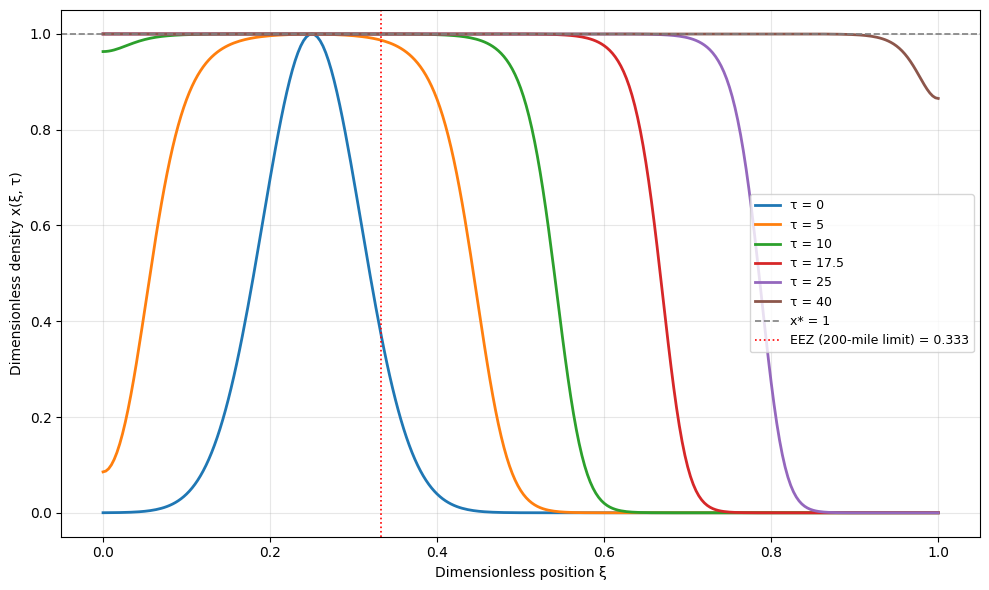

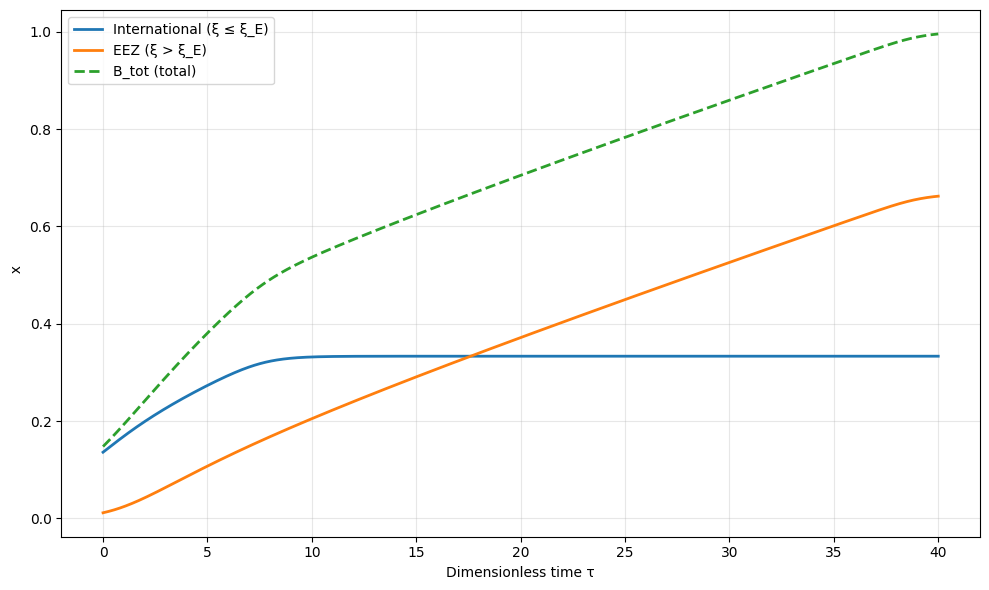

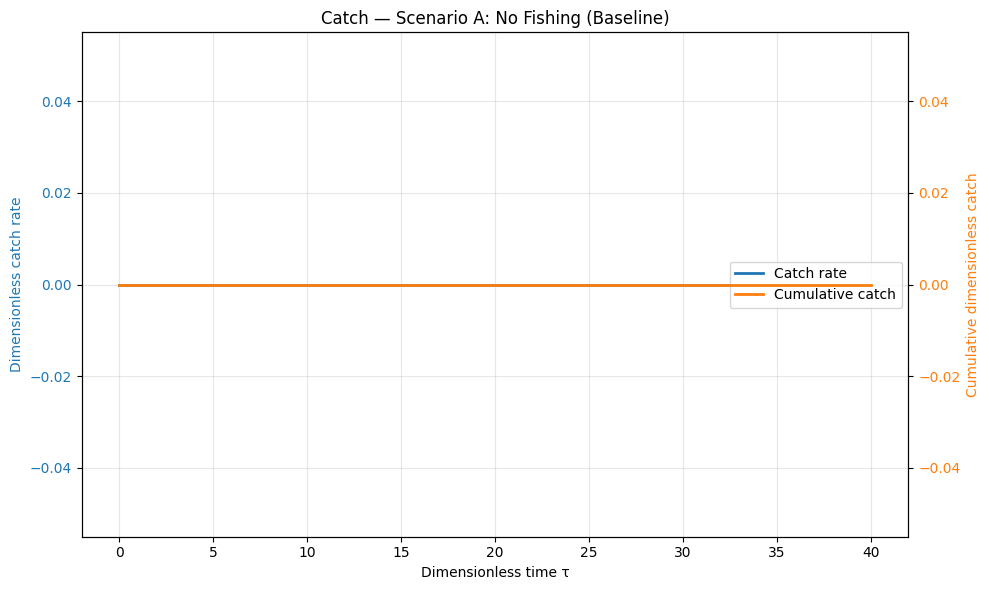

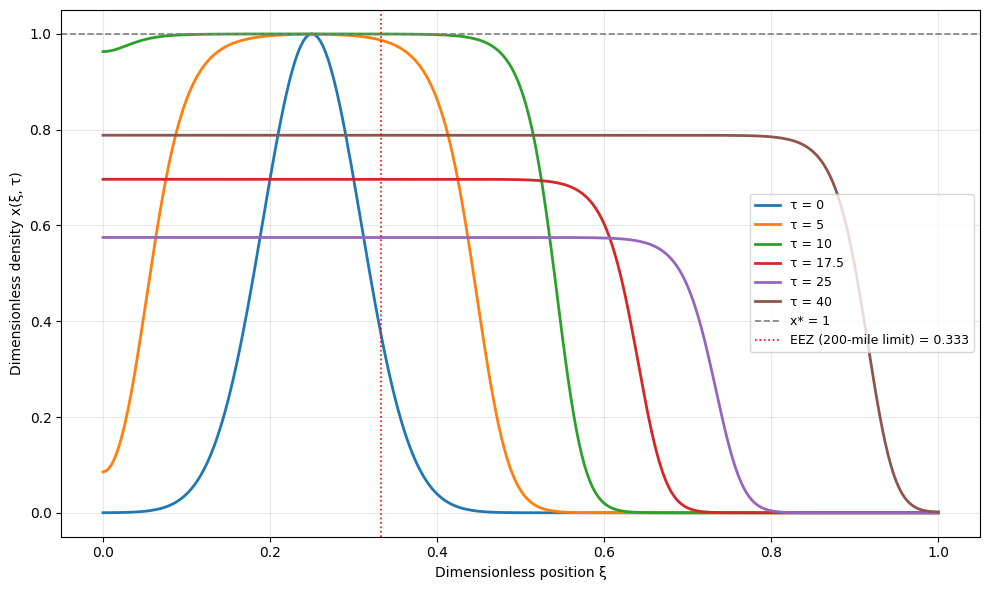

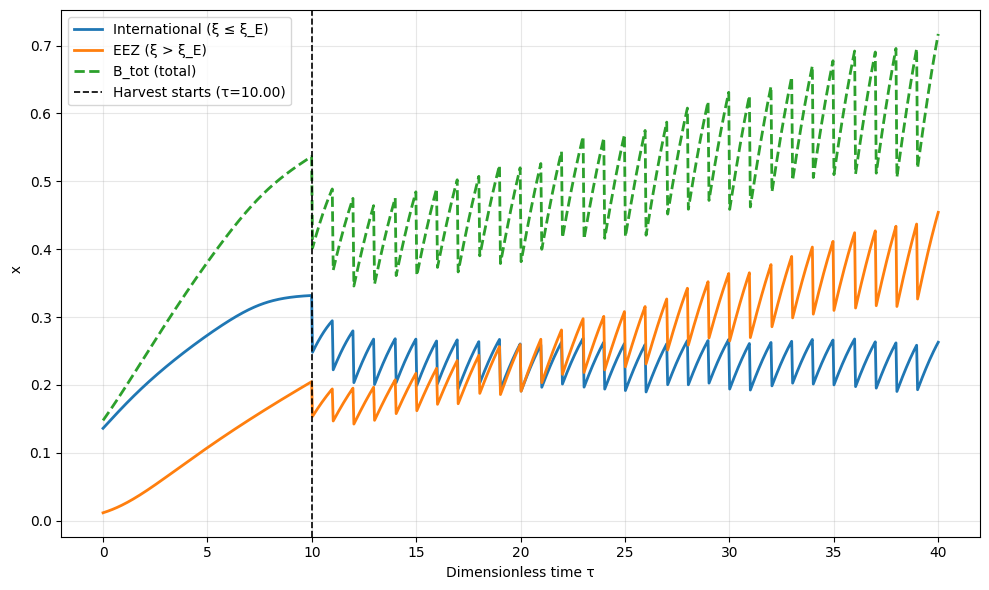

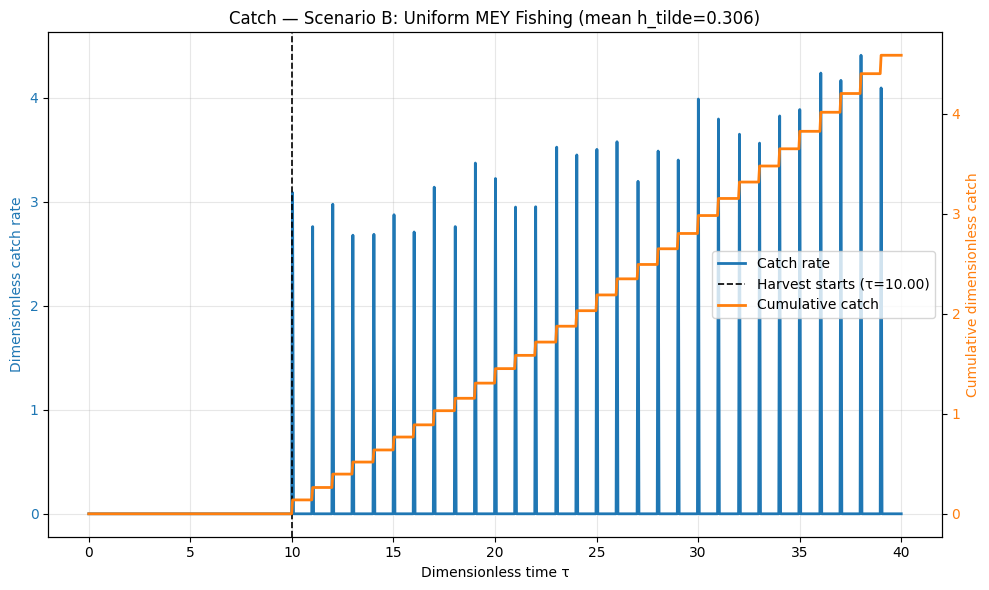

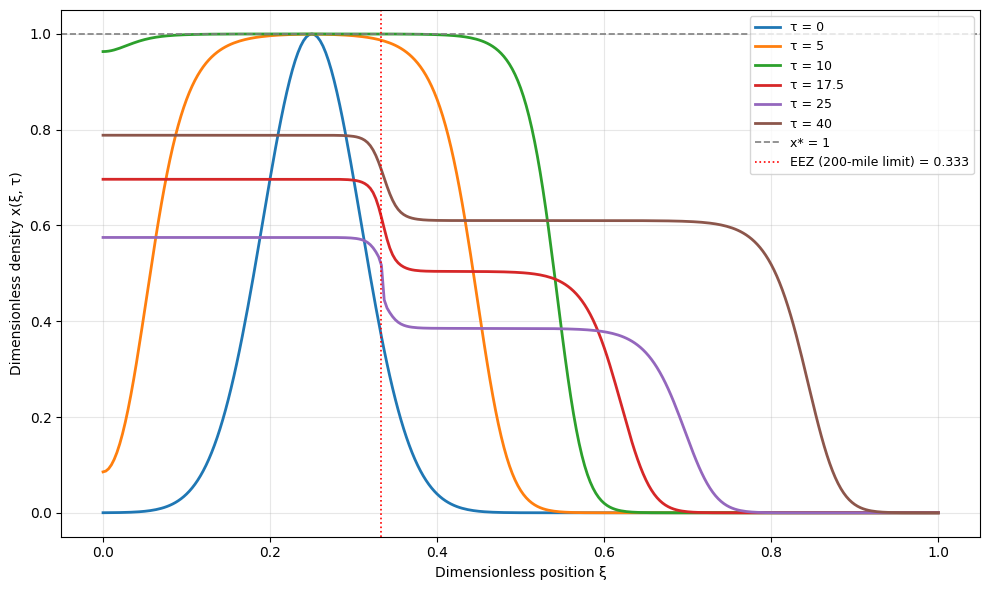

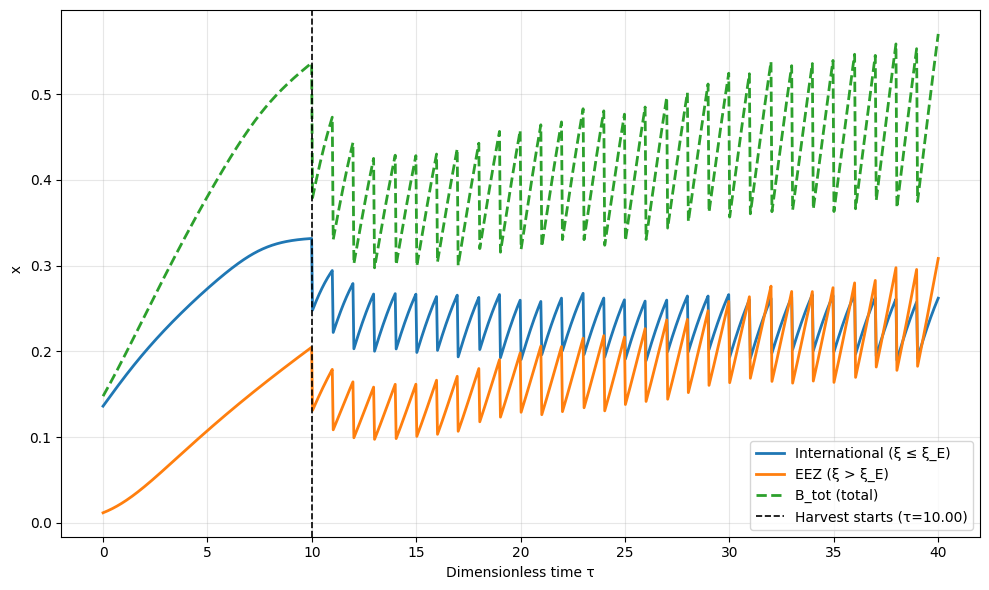

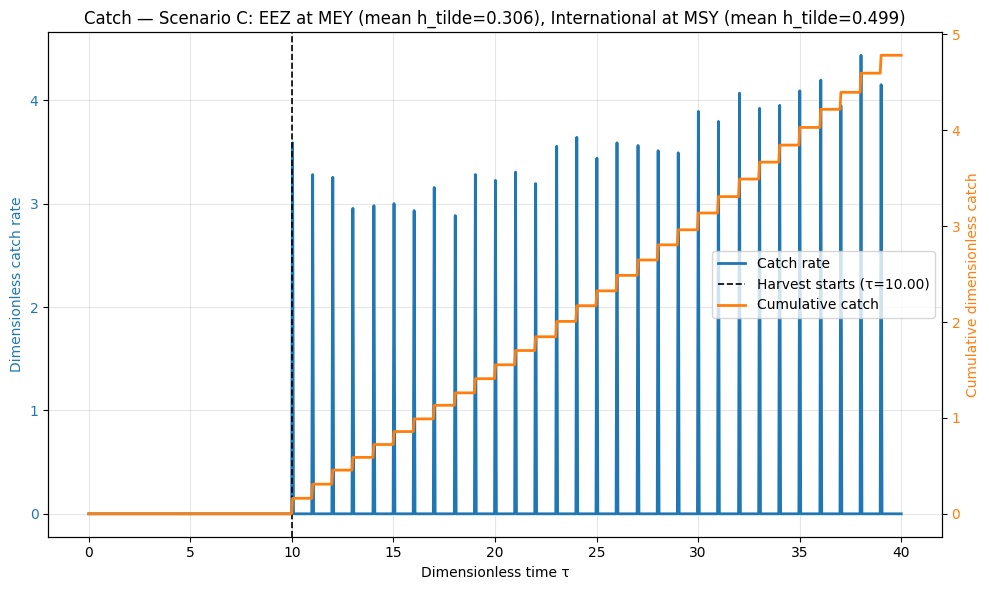

In [293]:
import numpy as np
from matplotlib import pyplot as plt

from plotting import plot_snapshots, plot_biomass, plot_catch

L_3c: float = 600.0
N_3c: int = 301
D_3c: float = 10.0
r_3c: float = 0.5
K_3c: float = 1.0
harvest_duration_3c: float = 60.0
S_BND: float = 200.0
n_tau_years_3c: int = int(np.ceil(r_3c * harvest_duration_3c))

EQ_REL_TOL_3C: float = 0.02
EQ_STREAK_3C: int = 3
EQ_SCAN_START_3C: float = 120.0
EQ_SCAN_STEP_3C: float = 60.0
EQ_SCAN_MAX_3C: float = 600.0

delta_3c: float = D_3c / (r_3c * L_3c**2)
xi_bnd: float = S_BND / L_3c


def build_phase_snapshots(warmup: float, harvest_duration: float, total_duration: float) -> list[float]:
    snaps = [
        0.0,
        0.5 * warmup,
        warmup,
        warmup + 0.25 * harvest_duration,
        warmup + 0.5 * harvest_duration,
        total_duration,
    ]
    ordered: list[float] = []
    for value in snaps:
        value = float(value)
        if not ordered or abs(value - ordered[-1]) > 1e-9:
            ordered.append(value)
    return ordered


def delayed_schedule_pulse_xy(
    schedule_arr: np.ndarray,
    start_time: float,
    r_scale: float,
) -> tuple[np.ndarray, np.ndarray]:
    schedule_arr = np.asarray(schedule_arr, dtype=float)
    if schedule_arr.size == 0:
        raise ValueError("schedule_arr must not be empty")
    if r_scale <= 0.0:
        raise ValueError("r_scale must be positive")
    tau_step_in_time = 1.0 / r_scale
    pulse_times = start_time + tau_step_in_time * np.arange(schedule_arr.size, dtype=float)
    return pulse_times, schedule_arr.copy()


def first_profile_equilibrium_time(
    t_full: np.ndarray,
    u_full: np.ndarray,
    target_profile: np.ndarray,
    rel_tol: float = EQ_REL_TOL_3C,
    streak: int = EQ_STREAK_3C,
) -> float | None:
    scale = max(float(np.max(np.abs(target_profile))), 1e-12)
    errors = np.max(np.abs(u_full - target_profile[None, :]), axis=1) / scale
    consecutive = 0
    for t_now, err in zip(t_full, errors):
        consecutive = consecutive + 1 if err <= rel_tol else 0
        if consecutive >= streak:
            return float(t_now)
    return None


def estimate_warmup_3c(gaussian_centers: list[float]) -> tuple[float, dict[float, float], float]:
    target_profile = np.full(N_3c, K_3c)
    scan_end = EQ_SCAN_START_3C
    while scan_end <= EQ_SCAN_MAX_3C:
        dense_frames = max(600, int(np.ceil(5.0 * scan_end)))
        eq_times: dict[float, float] = {}
        for center in gaussian_centers:
            ref = simulate_rd_fishing(
                L=L_3c,
                N=N_3c,
                D=D_3c,
                r=r_3c,
                K=K_3c,
                T_end=scan_end,
                s_boundary=S_BND,
                h_in=0.0,
                h_out=0.0,
                gaussian_center=center,
                store_full=True,
                full_n_frames=dense_frames,
            )
            eq_time = first_profile_equilibrium_time(ref["t_full"], ref["u_full"], target_profile)
            if eq_time is not None:
                eq_times[center] = eq_time
        if len(eq_times) == len(gaussian_centers):
            return max(eq_times.values()), eq_times, scan_end
        scan_end += EQ_SCAN_STEP_3C
    raise RuntimeError(
        f"3C warm-up did not reach equilibrium within {EQ_SCAN_MAX_3C:.1f} years."
    )


estimated_warmup_3c, eq_times_3c, warmup_scan_3c = estimate_warmup_3c([150.0, 200.0, 400.0])
tau_harvest_start_3c: float = 10.0
warmup_3c: float = tau_harvest_start_3c / r_3c
T_total_3c: float = warmup_3c + harvest_duration_3c
tau_end_3c: float = r_3c * T_total_3c
snapshot_times_3c = build_phase_snapshots(warmup_3c, harvest_duration_3c, T_total_3c)

print(f"delta = D/(r*L^2) = {delta_3c:.3e}, tau_end = {tau_end_3c:.1f}, xi_bnd = {xi_bnd:.4f}")
print(
    "3C equilibrium times by initial centre (years):",
    {int(center): round(eq_times_3c[center], 2) for center in sorted(eq_times_3c)},
)
print(
    f"3C estimated equilibrium warm-up = {estimated_warmup_3c:.2f} years; "
    f"using fixed harvest start at t={warmup_3c:.2f} years (tau = {tau_harvest_start_3c:.2f})"
)
print(f"3C total simulated time = {T_total_3c:.2f} years")

MEY_frac_arr = np.random.uniform(0.80, 0.90, size=n_tau_years_3c)
h_tilde_MEY_arr = (1.0 - np.sqrt(1.0 - MEY_frac_arr)) / 2.0
h_tilde_MSY_arr = 0.5 * np.random.uniform(0.90, 1.10, size=n_tau_years_3c)

h_MEY_arr = h_tilde_MEY_arr * r_3c
h_MSY_arr = h_tilde_MSY_arr * r_3c

print("Theoretical: h_tilde_MSY = 0.5000")
print(
    f"h_tilde_MEY mean={h_tilde_MEY_arr.mean():.4f}, "
    f"min={h_tilde_MEY_arr.min():.4f}, max={h_tilde_MEY_arr.max():.4f}"
)
print(
    f"h_tilde_MSY mean={h_tilde_MSY_arr.mean():.4f}, "
    f"min={h_tilde_MSY_arr.min():.4f}, max={h_tilde_MSY_arr.max():.4f}"
)

SCENARIOS = {
    "A": {
        "label": "No Fishing (Baseline)",
        "h_in": 0.0,
        "h_out": 0.0,
        "pulse": None,
        "h_in_schedule": None,
        "h_out_schedule": None,
    },
    "B": {
        "label": f"Uniform MEY Fishing (mean h_tilde={h_tilde_MEY_arr.mean():.3f})",
        "h_in": h_MEY_arr.mean(),
        "h_out": h_MEY_arr.mean(),
        "pulse": None,
        "h_in_schedule": h_MEY_arr,
        "h_out_schedule": h_MEY_arr,
    },
    "C": {
        "label": (
            f"EEZ at MEY (mean h_tilde={h_tilde_MEY_arr.mean():.3f}), "
            f"International at MSY (mean h_tilde={h_tilde_MSY_arr.mean():.3f})"
        ),
        "h_in": h_MEY_arr.mean(),
        "h_out": h_MSY_arr.mean(),
        "pulse": None,
        "h_in_schedule": h_MEY_arr,
        "h_out_schedule": h_MSY_arr,
    },
}

results_3c: dict[str, dict] = {}
full_frames_3c = max(300, int(np.ceil(4.0 * T_total_3c)))

for key, scen in SCENARIOS.items():
    res = simulate_rd_fishing(
        L=L_3c,
        N=N_3c,
        D=D_3c,
        r=r_3c,
        K=K_3c,
        T_end=T_total_3c,
        s_boundary=S_BND,
        h_in=scen["h_in"],
        h_out=scen["h_out"],
        pulse=scen["pulse"],
        snapshot_times=snapshot_times_3c,
        store_full=True,
        full_n_frames=full_frames_3c,
        h_in_schedule=scen["h_in_schedule"],
        h_out_schedule=scen["h_out_schedule"],
        harvest_start_time=warmup_3c,
    )
    results_3c[key] = res


def to_nd(res: dict, L: float, r: float, K: float) -> dict:
    nd = {
        "s": res["s"] / L,
        "time": res["time"] * r,
        "snapshots": {t * r: snap / K for t, snap in res["snapshots"].items()},
        "B_in": res["B_in"] / (K * L),
        "B_out": res["B_out"] / (K * L),
        "B_tot": res["B_tot"] / (K * L),
        "Catch": res["Catch"] / (r * K * L),
        "CumCatch": res["CumCatch"] / (K * L),
        "s_boundary": res["s_boundary"] / L,
        "min_u": res["min_u"] / K,
        "harvest_start_time": res.get("harvest_start_time", 0.0) * r,
    }
    if "u_full" in res:
        nd["u_full"] = res["u_full"] / K
        nd["t_full"] = res["t_full"] * r
    return nd


results_3c_nd = {k: to_nd(v, L_3c, r_3c, K_3c) for k, v in results_3c.items()}

for key, scen in SCENARIOS.items():
    res_nd = results_3c_nd[key]
    tag = f"Scenario {key}: {scen['label']}"

    plot_snapshots(res_nd, tag, K=K_3c)
    plot_biomass(res_nd, tag)
    plot_catch(res_nd, tag)

plt.show()


## Heatmap Visualisations - Scenarios A, B, C (3C(i))

For each of the three policy scenarios we plot the **full space-time density field** $u(s,t)$ as a heatmap:

1. **Heatmap** - offshore distance $s$ vs time $t$ vs fish density $u$, with the 200-mile policy boundary marked.

The equivalent visualisations for **3C(ii)** (fish origin outside the EEZ) are produced in the sub-section below.

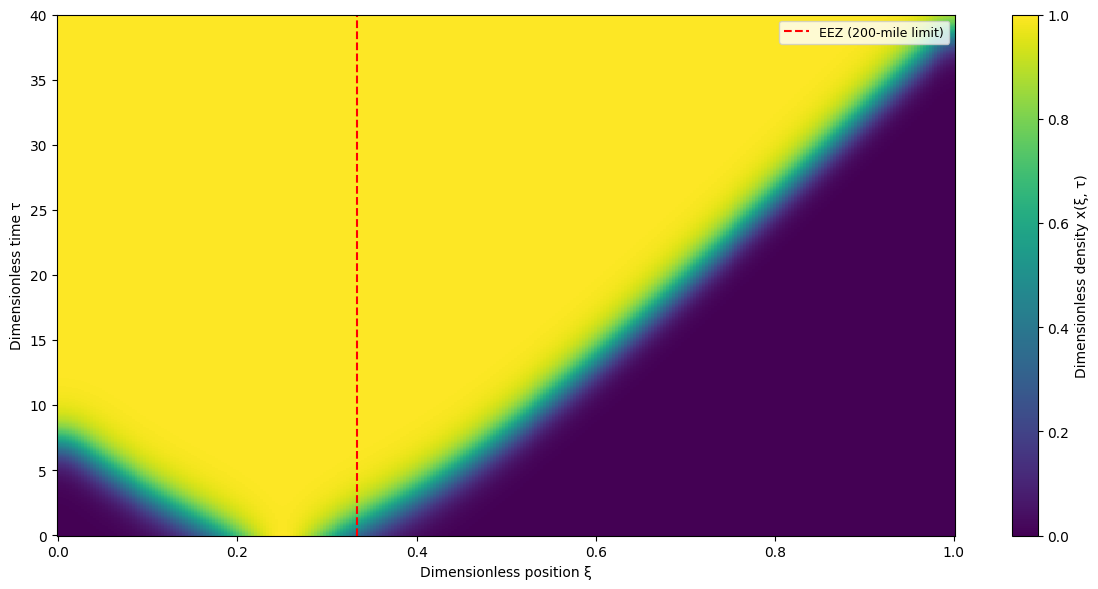

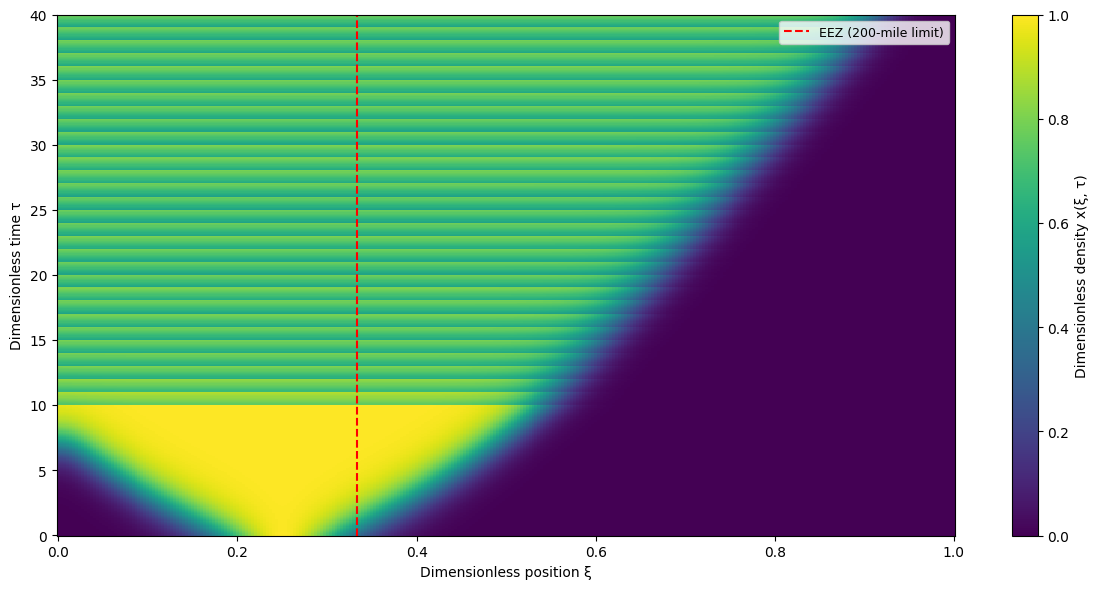

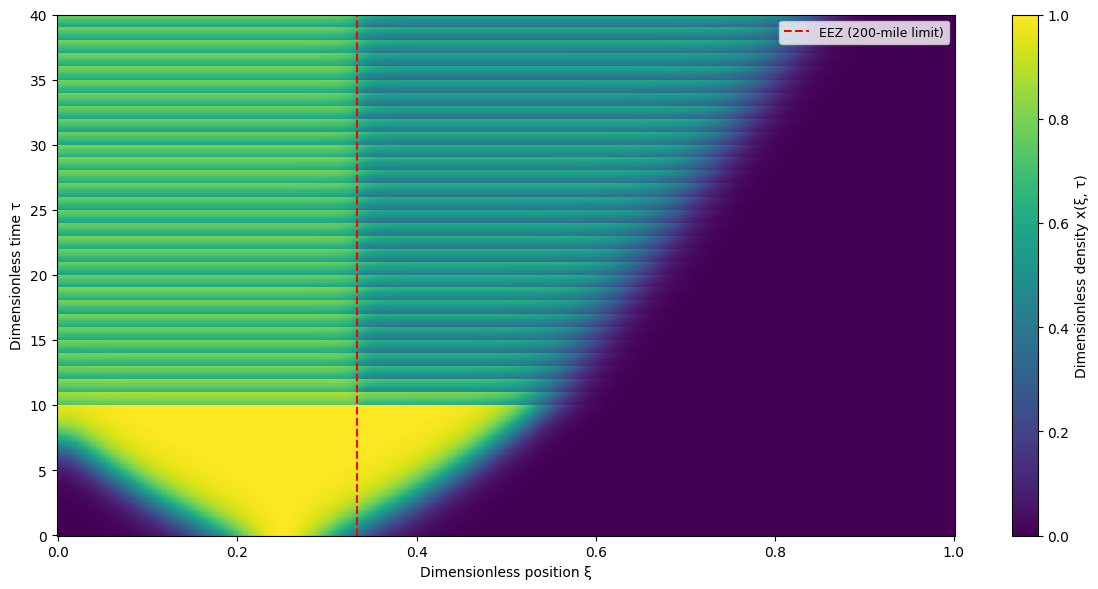

In [294]:
from matplotlib import pyplot as plt

from plotting import plot_3d_surface, plot_3d_surface_plotly, plot_heatmap

for key, scen in SCENARIOS.items():
    res_nd = results_3c_nd[key]
    tag = f"Scenario {key}: {scen['label']}"

    # plot_3d_surface(res_nd["s"], res_nd["t_full"], res_nd["u_full"], tag, res_nd["s_boundary"])
    # plot_3d_surface_plotly(res_nd["s"], res_nd["t_full"], res_nd["u_full"], tag)
    plot_heatmap(res_nd["s"], res_nd["t_full"], res_nd["u_full"], tag, res_nd["s_boundary"])

plt.show()

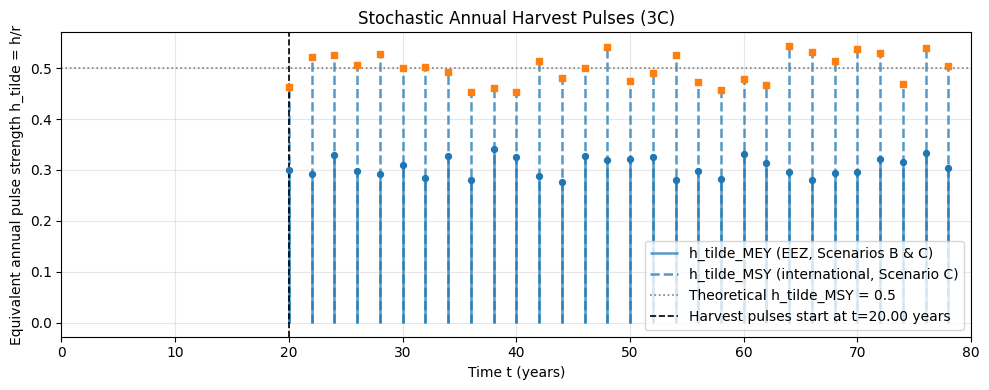

In [295]:
fig_sched, ax_sched = plt.subplots(figsize=(10, 4))

mey_time, mey_rate = delayed_schedule_pulse_xy(h_tilde_MEY_arr, warmup_3c, r_3c)
msy_time, msy_rate = delayed_schedule_pulse_xy(h_tilde_MSY_arr, warmup_3c, r_3c)

ax_sched.vlines(
    mey_time,
    0.0,
    mey_rate,
    linewidth=1.8,
    alpha=0.75,
    label="h_tilde_MEY (EEZ, Scenarios B & C)",
)
ax_sched.scatter(mey_time, mey_rate, s=18, zorder=3)
ax_sched.vlines(
    msy_time,
    0.0,
    msy_rate,
    linewidth=1.8,
    linestyles="--",
    alpha=0.75,
    label="h_tilde_MSY (international, Scenario C)",
)
ax_sched.scatter(msy_time, msy_rate, s=18, marker="s", zorder=3)
ax_sched.axhline(
    0.5,
    color="gray",
    linestyle=":",
    linewidth=1.2,
    label="Theoretical h_tilde_MSY = 0.5",
)
ax_sched.axvline(
    warmup_3c,
    color="black",
    linestyle="--",
    linewidth=1.2,
    label=f"Harvest pulses start at t={warmup_3c:.2f} years",
)

ax_sched.set_xlim(0.0, T_total_3c)
ax_sched.set_xlabel("Time t (years)")
ax_sched.set_ylabel("Equivalent annual pulse strength h_tilde = h/r")
ax_sched.set_title("Stochastic Annual Harvest Pulses (3C)")
ax_sched.legend()
ax_sched.grid(True, alpha=0.3)
fig_sched.tight_layout()
plt.show()


## 3C (ii) Ã¢â‚¬â€ Scenario C: Fish Origin Outside the 200-Mile Limit

Same fishing policy as Scenario C (MEY inside EEZ, MSY in international waters), but the initial fish population is a **Gaussian centred at $s = 400$ miles** (international waters) rather than $s = 150$ miles.

This sub-case tests:
- Whether the long-run equilibrium is **robust to initial conditions** (attractor robustness).
- How fish **migrate inshore** from a heavily-fished starting location into the lower-pressure EEZ via diffusion.
- How the biomass split between $B_{\rm in}$ and $B_{\rm out}$ evolves differently compared to the inshore-origin case.

The same stochastic harvest schedules (`h_MEY_arr`, `h_MSY_arr`) drawn above are reused, isolating the effect of the initial condition.

In [296]:
XI_GAUSS_OUT: float = 400.0 / L_3c
GAUSS_OUT_DIM: float = 400.0

res_C_out = simulate_rd_fishing(
    L=L_3c,
    N=N_3c,
    D=D_3c,
    r=r_3c,
    K=K_3c,
    T_end=T_total_3c,
    s_boundary=S_BND,
    h_in=h_MEY_arr.mean(),
    h_out=h_MSY_arr.mean(),
    h_in_schedule=h_MEY_arr,
    h_out_schedule=h_MSY_arr,
    gaussian_center=GAUSS_OUT_DIM,
    snapshot_times=snapshot_times_3c,
    store_full=True,
    full_n_frames=full_frames_3c,
    harvest_start_time=warmup_3c,
)
res_C_out_nd = to_nd(res_C_out, L_3c, r_3c, K_3c)

tag_C_out = (
    f"Scenario C (origin outside EEZ, xi0={XI_GAUSS_OUT:.3f}): "
    f"EEZ at MEY (mean h_tilde={h_tilde_MEY_arr.mean():.3f}), "
    f"International at MSY (mean h_tilde={h_tilde_MSY_arr.mean():.3f})"
)
print(
    f"Simulation complete. min(x) = {res_C_out_nd['min_u']:.4e}; "
    f"harvest starts at t={warmup_3c:.2f} years"
)


Simulation complete. min(x) = 1.6038e-28; harvest starts at t=20.00 years


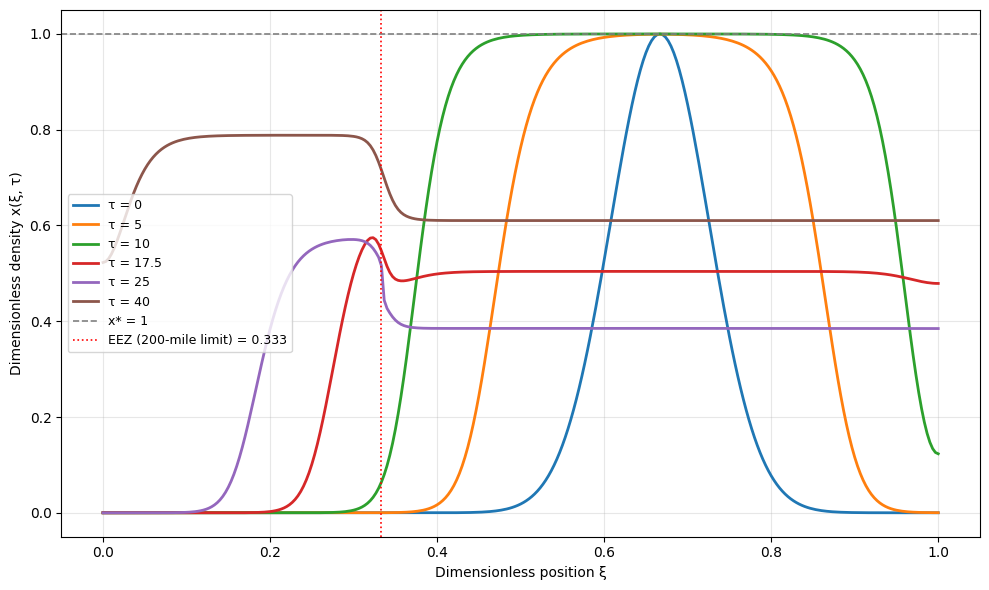

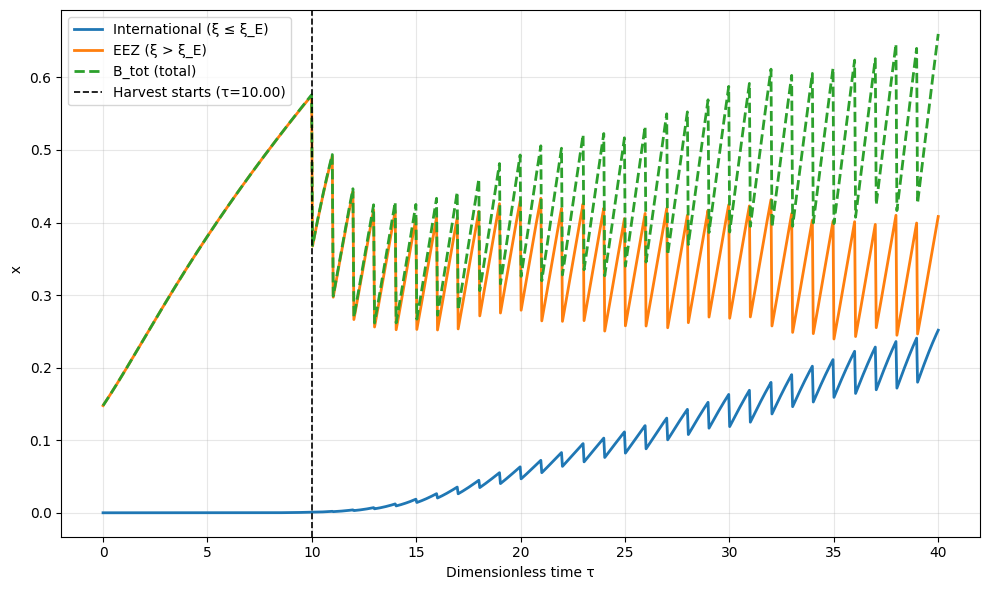

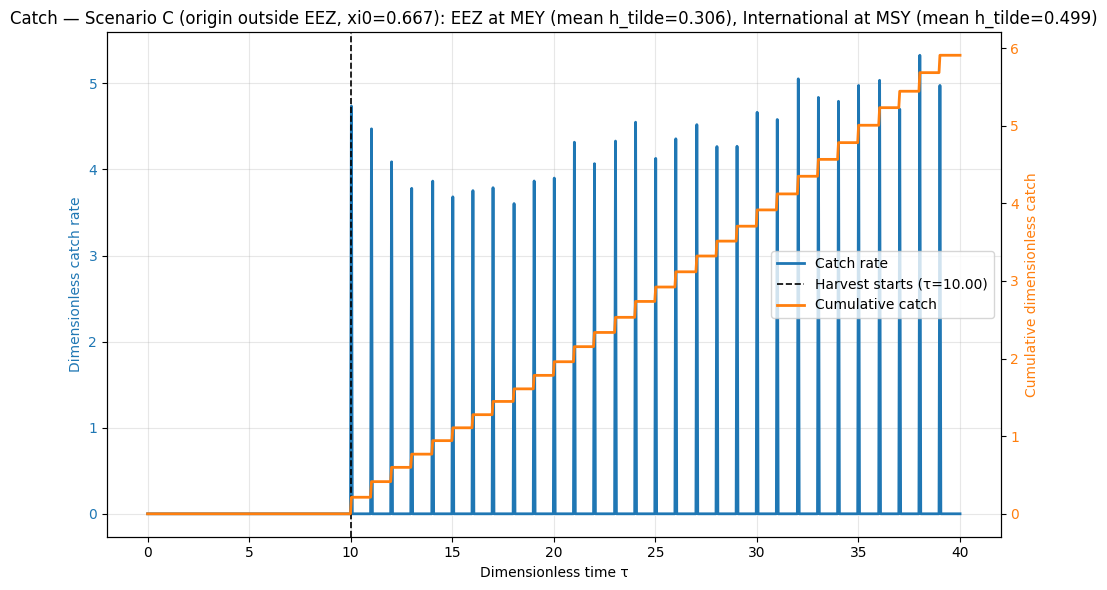

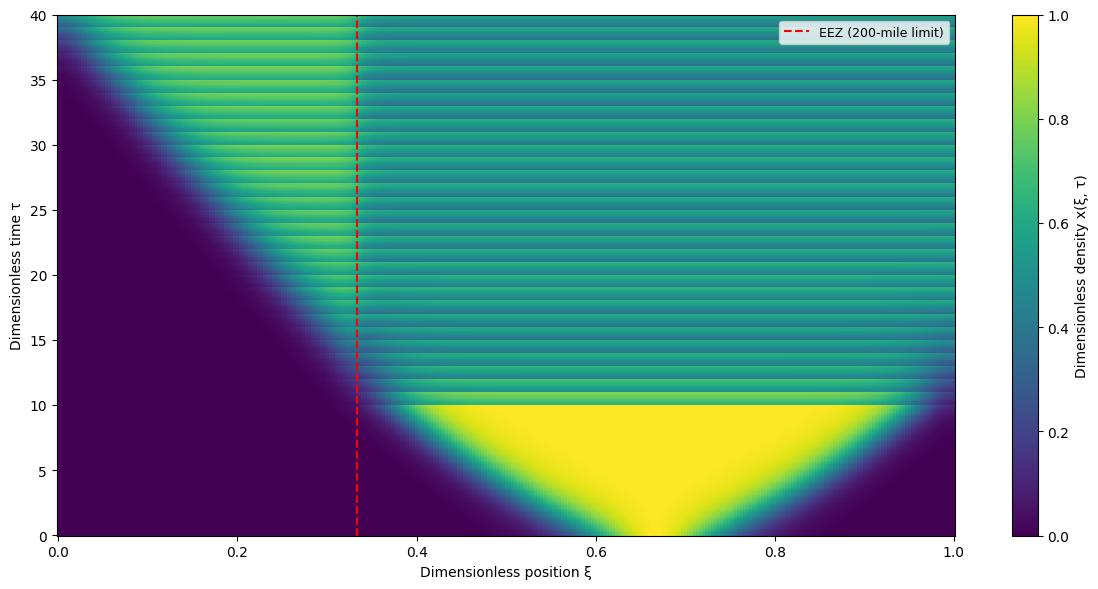

In [297]:
from plotting import plot_snapshots, plot_biomass, plot_catch, plot_3d_surface, plot_3d_surface_plotly, plot_heatmap

plot_snapshots(res_C_out_nd, tag_C_out, K=K_3c)
plot_biomass(res_C_out_nd, tag_C_out)
plot_catch(res_C_out_nd, tag_C_out)
# plot_3d_surface(res_C_out_nd["s"], res_C_out_nd["t_full"], res_C_out_nd["u_full"],
#                 tag_C_out, res_C_out_nd["s_boundary"])
# plot_3d_surface_plotly(res_C_out_nd["s"], res_C_out_nd["t_full"], res_C_out_nd["u_full"], tag_C_out)
plot_heatmap(res_C_out_nd["s"], res_C_out_nd["t_full"], res_C_out_nd["u_full"],
             tag_C_out, res_C_out_nd["s_boundary"])

plt.show()

### Scenario C - Effect of Fish Origin on Biomass Dynamics

(same fishing policy, with harvest starting at tau = 10)


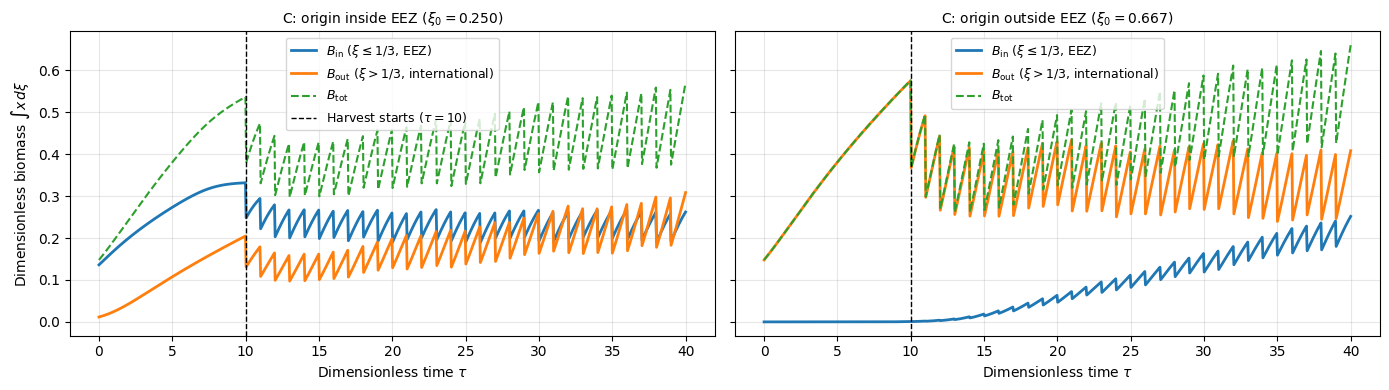

In [298]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)

cases = [
    (results_3c_nd["C"], r"C: origin inside EEZ ($\xi_0 = 0.250$)"),
    (res_C_out_nd, rf"C: origin outside EEZ ($\xi_0 = {XI_GAUSS_OUT:.3f}$)"),
]

for idx, (ax, (res_nd, lbl)) in enumerate(zip(axes, cases)):
    ax.plot(res_nd["time"], res_nd["B_in"], linewidth=2.0, label=r"$B_{\mathrm{in}}$ ($\xi \leq 1/3$, EEZ)")
    ax.plot(res_nd["time"], res_nd["B_out"], linewidth=2.0, label=r"$B_{\mathrm{out}}$ ($\xi > 1/3$, international)")
    ax.plot(res_nd["time"], res_nd["B_tot"], linewidth=1.5, linestyle="--", label=r"$B_{\mathrm{tot}}$")
    if np.any(np.asarray(res_nd["Catch"]) > 0.0):
        ax.axvline(
            res_nd["harvest_start_time"],
            color="black",
            linestyle="--",
            linewidth=1.0,
            label=rf"Harvest starts ($\tau = {res_nd['harvest_start_time']:g}$)" if idx == 0 else None,
        )
    ax.set_title(lbl, fontsize=10)
    ax.set_xlabel(r"Dimensionless time $\tau$")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel(r"Dimensionless biomass $\int x\, d\xi$")
# fig.suptitle(
#     "Scenario C - Effect of Fish Origin on Biomass Dynamics\n"
#     "(same fishing policy, with harvest starting at tau = 10)",
#     fontsize=11,
# )
plt.tight_layout()
plt.show()


## 3C (iii) Ã¢â‚¬â€ Scenario C: Fish Origin ON the 200-Mile Boundary

Same fishing policy as Scenario C (MEY inside EEZ, MSY in international waters), but the initial fish population is a **Gaussian centred exactly at $s = 200$ km** Ã¢â‚¬â€ directly on the EEZ boundary ($\xi_0 = 1/3$).

This sub-case tests:
- How the population evolves when the initial biomass is **split symmetrically across the policy boundary**.
- Whether fish diffuse preferentially inshore (lower fishing pressure) or offshore.
- How this compares to origins fully inside ($\xi_0 = 0.25$) and fully outside ($\xi_0 = 2/3$) the EEZ.

The same stochastic harvest schedules (`h_MEY_arr`, `h_MSY_arr`) drawn above are reused.

Simulation complete. min(x) = 1.6038e-28; harvest starts at t=20.00 years


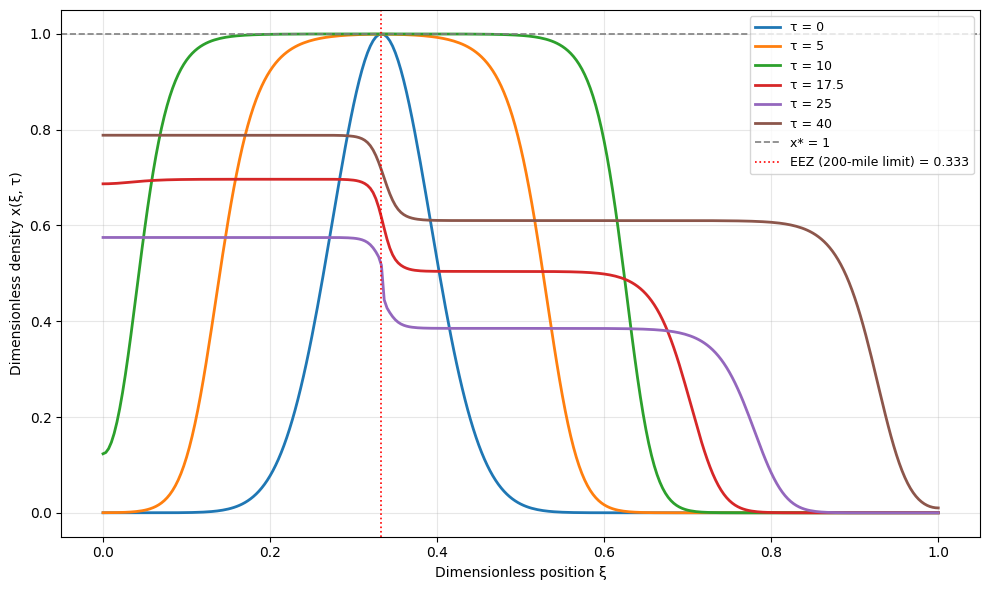

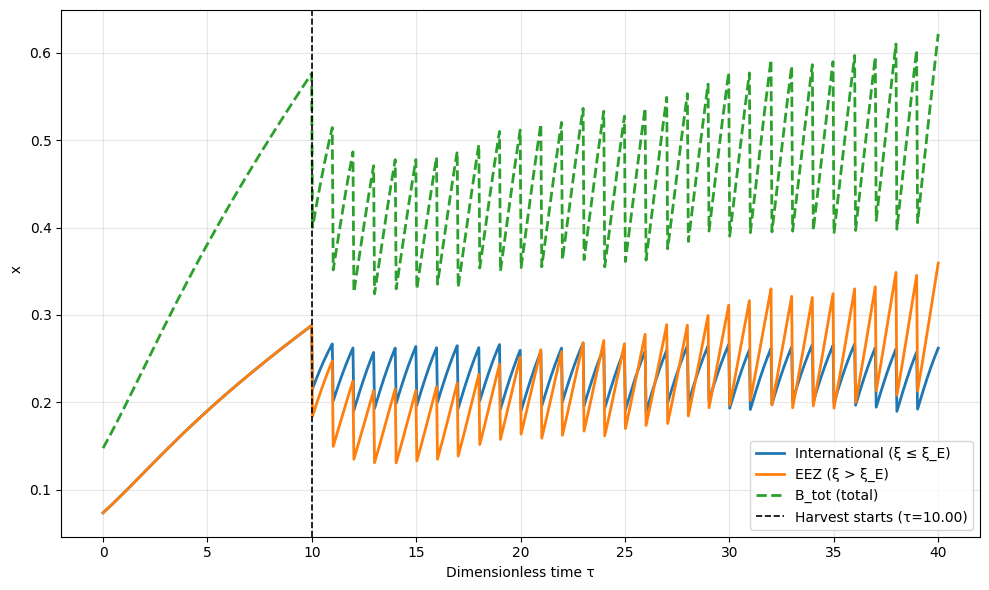

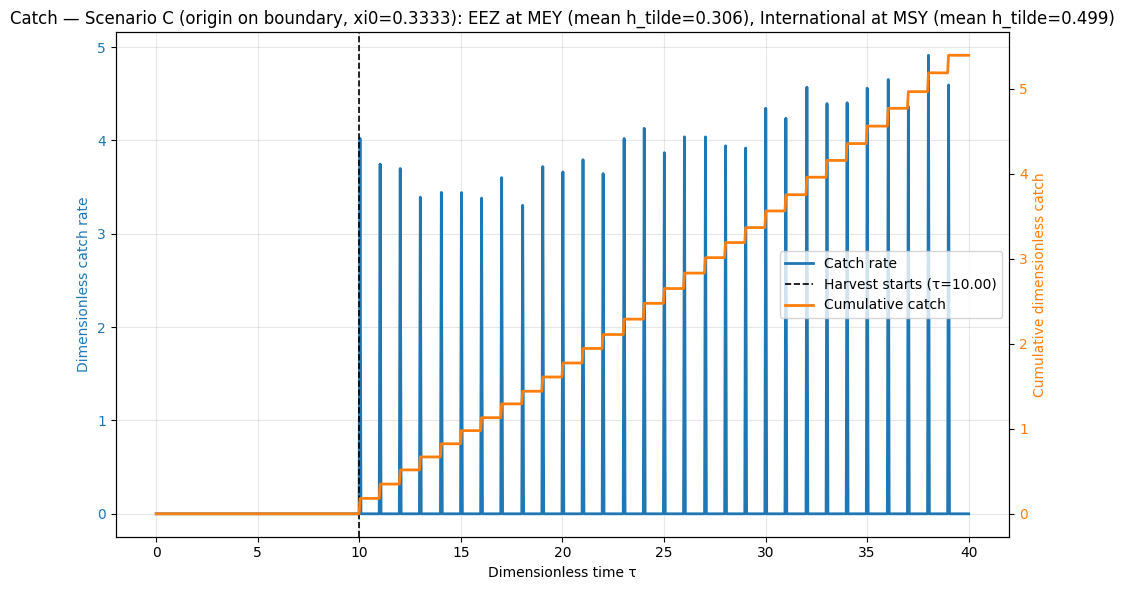

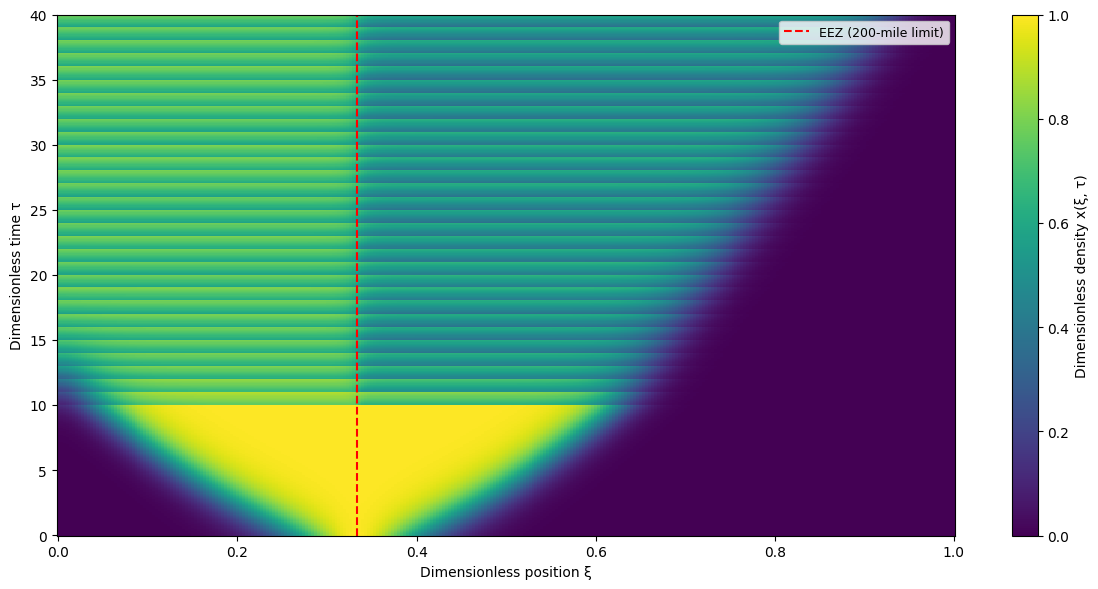

In [299]:
from plotting import plot_snapshots, plot_biomass, plot_catch, plot_3d_surface, plot_3d_surface_plotly, plot_heatmap

XI_GAUSS_BND: float = 200.0 / L_3c
GAUSS_BND_DIM: float = 200.0

res_C_bnd = simulate_rd_fishing(
    L=L_3c,
    N=N_3c,
    D=D_3c,
    r=r_3c,
    K=K_3c,
    T_end=T_total_3c,
    s_boundary=S_BND,
    h_in=h_MEY_arr.mean(),
    h_out=h_MSY_arr.mean(),
    h_in_schedule=h_MEY_arr,
    h_out_schedule=h_MSY_arr,
    gaussian_center=GAUSS_BND_DIM,
    snapshot_times=snapshot_times_3c,
    store_full=True,
    full_n_frames=full_frames_3c,
    harvest_start_time=warmup_3c,
)
res_C_bnd_nd = to_nd(res_C_bnd, L_3c, r_3c, K_3c)

tag_C_bnd = (
    f"Scenario C (origin on boundary, xi0={XI_GAUSS_BND:.4f}): "
    f"EEZ at MEY (mean h_tilde={h_tilde_MEY_arr.mean():.3f}), "
    f"International at MSY (mean h_tilde={h_tilde_MSY_arr.mean():.3f})"
)
print(
    f"Simulation complete. min(x) = {res_C_bnd_nd['min_u']:.4e}; "
    f"harvest starts at t={warmup_3c:.2f} years"
)

plot_snapshots(res_C_bnd_nd, tag_C_bnd, K=K_3c)
plot_biomass(res_C_bnd_nd, tag_C_bnd)
plot_catch(res_C_bnd_nd, tag_C_bnd)
# plot_3d_surface(
#     res_C_bnd_nd["s"],
#     res_C_bnd_nd["t_full"],
#     res_C_bnd_nd["u_full"],
#     tag_C_bnd,
#     res_C_bnd_nd["s_boundary"],
# )
# plot_3d_surface_plotly(
#     res_C_bnd_nd["s"],
#     res_C_bnd_nd["t_full"],
#     res_C_bnd_nd["u_full"],
#     tag_C_bnd,
# )
plot_heatmap(
    res_C_bnd_nd["s"],
    res_C_bnd_nd["t_full"],
    res_C_bnd_nd["u_full"],
    tag_C_bnd,
    res_C_bnd_nd["s_boundary"],
)

plt.show()

### Scenario C - Effect of Fish Origin on Biomass Dynamics

(same fishing policy, with harvest starting at tau = 10)


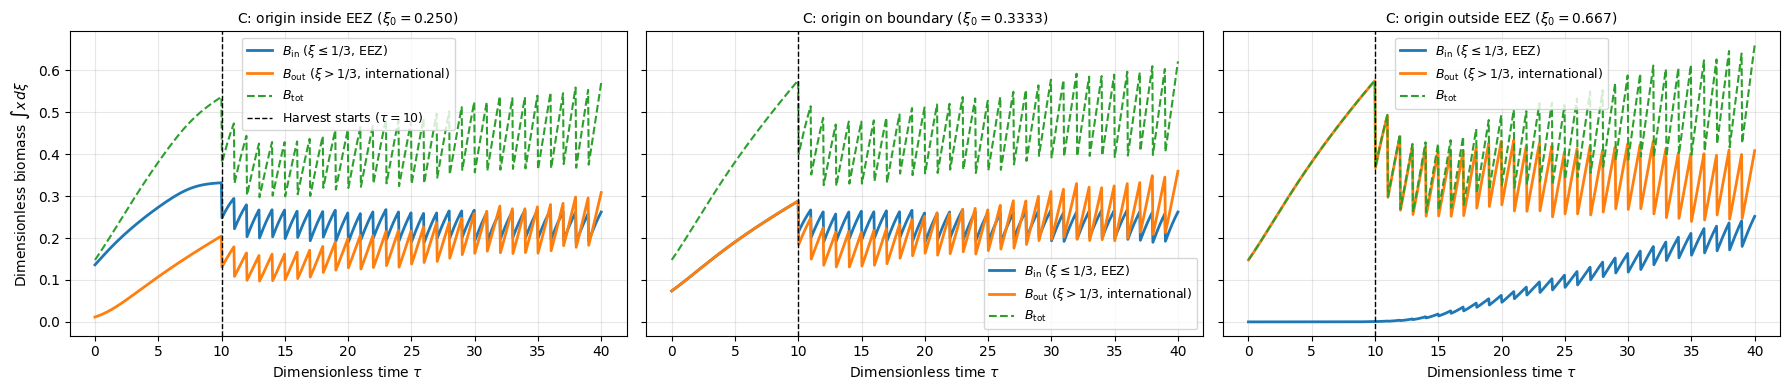

In [300]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharey=True)

cases = [
    (results_3c_nd["C"], r"C: origin inside EEZ ($\xi_0 = 0.250$)"),
    (res_C_bnd_nd, rf"C: origin on boundary ($\xi_0 = {XI_GAUSS_BND:.4f}$)"),
    (res_C_out_nd, rf"C: origin outside EEZ ($\xi_0 = {XI_GAUSS_OUT:.3f}$)"),
]

for idx, (ax, (res_nd, lbl)) in enumerate(zip(axes, cases)):
    ax.plot(res_nd["time"], res_nd["B_in"], linewidth=2.0, label=r"$B_{\mathrm{in}}$ ($\xi \leq 1/3$, EEZ)")
    ax.plot(res_nd["time"], res_nd["B_out"], linewidth=2.0, label=r"$B_{\mathrm{out}}$ ($\xi > 1/3$, international)")
    ax.plot(res_nd["time"], res_nd["B_tot"], linewidth=1.5, linestyle="--", label=r"$B_{\mathrm{tot}}$")
    if np.any(np.asarray(res_nd["Catch"]) > 0.0):
        ax.axvline(
            res_nd["harvest_start_time"],
            color="black",
            linestyle="--",
            linewidth=1.0,
            label=rf"Harvest starts ($\tau = {res_nd['harvest_start_time']:g}$)" if idx == 0 else None,
        )
    ax.set_title(lbl, fontsize=10)
    ax.set_xlabel(r"Dimensionless time $\tau$")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel(r"Dimensionless biomass $\int x\, d\xi$")
# fig.suptitle(
#     "Scenario C - Effect of Fish Origin on Biomass Dynamics\n"
#     "(same fishing policy, with harvest starting at tau = 10)",
#     fontsize=11,
# )
plt.tight_layout()
plt.show()


# 4A Ã¢â‚¬â€ Pure Diffusion: Two-Species Migration

**Purpose:** validate the two-species spatial discretisation with no-flux Neumann boundaries *before* adding logistic growth, competition, or fishing.

Using $x = u/K_1$, $y = v/K_2$, $\xi = s/L$, $\tau = r_1 t$ the dimensional diffusion PDEs become:

$$\frac{\partial x}{\partial \tau} = \delta_1\,\frac{\partial^2 x}{\partial \xi^2},\qquad \frac{\partial y}{\partial \tau} = \delta_2\,\frac{\partial^2 y}{\partial \xi^2}$$

with $\delta_i = D_i/(r_1 L^2)$ and no-flux boundaries.  The two species diffuse **independently** Ã¢â‚¬â€ no competition term yet.

**Expected behaviour:**
- Each Gaussian bump spreads and flattens toward a uniform distribution.
- Mass $M_i(\tau) = \int_0^1 x_i\,d\xi$ is conserved separately for each species.

delta1=5.556e-05,  delta2=5.556e-05,  tau_end=50.0
dt=4.49640e-02,  nt=1112


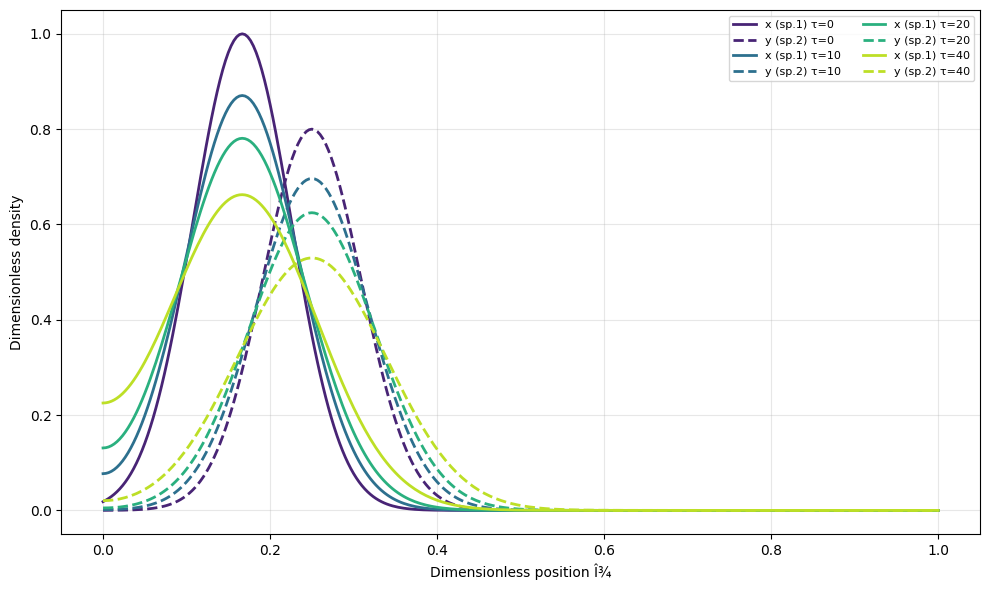

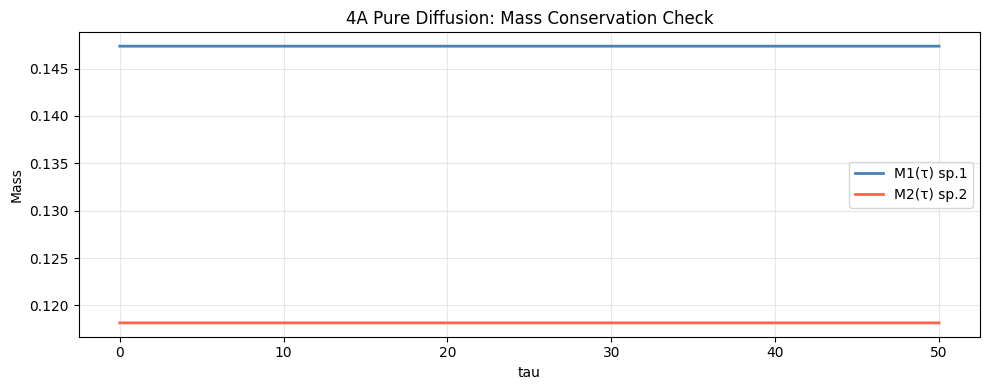

In [301]:
import numpy as np
from matplotlib import pyplot as plt
from pde_solver import laplacian_neumann

# Ã¢â€â‚¬Ã¢â€â‚¬ Parameters (reuse Ã‚Â§3B grid in ND form) Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬
L_rd_4a: float = 600.0
N_rd_4a: int   = 301
r1_4a:   float = 0.5
D1_4a:   float = 10.0
D2_4a:   float = 10.0
T_end_4a_dim: float = 100.0

dxi_4a   = 1.0 / (N_rd_4a - 1)
tau_end_4a = r1_4a * T_end_4a_dim
xi_4a = np.linspace(0.0, 1.0, N_rd_4a)
delta1_4a = D1_4a / (r1_4a * L_rd_4a**2)
delta2_4a = D2_4a / (r1_4a * L_rd_4a**2)
print(f"delta1={delta1_4a:.3e},  delta2={delta2_4a:.3e},  tau_end={tau_end_4a:.1f}")

dtau_4a = 0.45 * dxi_4a**2 / (2.0 * max(delta1_4a, delta2_4a))
nt_4a   = int(np.ceil(tau_end_4a / dtau_4a))
dtau_4a = tau_end_4a / nt_4a
print(f"dt={dtau_4a:.5e},  nt={nt_4a}")

# Ã¢â€â‚¬Ã¢â€â‚¬ Initial conditions Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬
xi_peak1 = 100.0 / L_rd_4a
xi_peak2 = 150.0 / L_rd_4a
sig_4a   =  50.0 / L_rd_4a
x_4a = np.exp(-((xi_4a - xi_peak1) / sig_4a)**2)
y_4a = 0.8 * np.exp(-((xi_4a - xi_peak2) / sig_4a)**2)

snap_times_4a = {0.0,10.0, 20,40}
snaps_x4a: dict = {0.0: x_4a.copy()}
snaps_y4a: dict = {0.0: y_4a.copy()}
mass_x4a = np.empty(nt_4a + 1);  mass_y4a = np.empty(nt_4a + 1)
tau_hist4a = np.empty(nt_4a + 1)
mass_x4a[0] = np.trapezoid(x_4a, xi_4a);  mass_y4a[0] = np.trapezoid(y_4a, xi_4a)
tau_hist4a[0] = 0.0

for n in range(1, nt_4a + 1):
    x_4a = x_4a + dtau_4a * delta1_4a * laplacian_neumann(x_4a, dxi_4a)
    y_4a = y_4a + dtau_4a * delta2_4a * laplacian_neumann(y_4a, dxi_4a)
    tau4a = n * dtau_4a
    mass_x4a[n] = np.trapezoid(x_4a, xi_4a)
    mass_y4a[n] = np.trapezoid(y_4a, xi_4a)
    tau_hist4a[n] = tau4a
    for ts in list(snap_times_4a):
        if abs(tau4a - ts) < 0.5 * dtau_4a:
            snaps_x4a[ts] = x_4a.copy();  snaps_y4a[ts] = y_4a.copy()
            snap_times_4a.discard(ts)

colors4a = plt.cm.viridis(np.linspace(0.1, 0.9, len(snaps_x4a)))
fig, ax = plt.subplots(figsize=(10, 6))
for i, ts in enumerate(sorted(snaps_x4a)):
    ax.plot(xi_4a, snaps_x4a[ts], color=colors4a[i], ls='-',  lw=2.0, label=f'x (sp.1) \u03c4={ts:g}')
    ax.plot(xi_4a, snaps_y4a[ts], color=colors4a[i], ls='--', lw=2.0, label=f'y (sp.2) \u03c4={ts:g}')
#ax.set_title('4A Pure Diffusion (ND): Two-Species Density Snapshots')
ax.set_xlabel('Dimensionless position Î¾');  ax.set_ylabel('Dimensionless density')
ax.grid(True, alpha=0.3);  ax.legend(fontsize=8, ncol=2)
plt.tight_layout();  plt.show()

fig2, ax2 = plt.subplots(figsize=(10, 4))
ax2.plot(tau_hist4a, mass_x4a, lw=2.0, color='steelblue', label='M1(\u03c4) sp.1')
ax2.plot(tau_hist4a, mass_y4a, lw=2.0, color='tomato',    label='M2(\u03c4) sp.2')
ax2.set_title('4A Pure Diffusion: Mass Conservation Check')
ax2.set_xlabel('tau');  ax2.set_ylabel('Mass')
ax2.grid(True, alpha=0.3);  ax2.legend()
plt.tight_layout();  plt.show()

# 4B Ã¢â‚¬â€ ReactionÃ¢â‚¬â€œDiffusion: Two-Species Logistic Competition (No Fishing)

Using $x = u/K_1$, $y = v/K_2$, $\xi = s/L$, $\tau = r_1 t$, $\rho = r_2/r_1$, $\delta_i = D_i/(r_1 L^2)$:

$$\frac{\partial x}{\partial \tau} = x(1 - x - \beta_{12}\,y) + \delta_1\,\frac{\partial^2 x}{\partial \xi^2}$$
$$\frac{\partial y}{\partial \tau} = \rho\,y(1 - y - \beta_{21}\,x) + \delta_2\,\frac{\partial^2 y}{\partial \xi^2}$$

with $\beta_{12} = \alpha K_2/K_1$ and $\beta_{21} = \beta K_1/K_2$.

**Two sub-experiments:**
- **(A) Non-uniform IC** Ã¢â‚¬â€ three competition scenarios: balanced coexistence, competitive exclusion, and diffusion asymmetry.
- **(B) Uniform IC validation** Ã¢â‚¬â€ $x_0 = y_0 = 0.2$; spatial means should match the competing-species ODE (no diffusion).

[A  (balanced)] final x: min=0.0000 max=0.6670; y: min=0.0000 max=0.9870


C:\Users\Bakri\AppData\Local\Temp\ipykernel_18424\316528000.py:61: UserWarning: Glyph 157 (\x9d) missing from font(s) DejaVu Sans.
  plt.tight_layout();  plt.show()


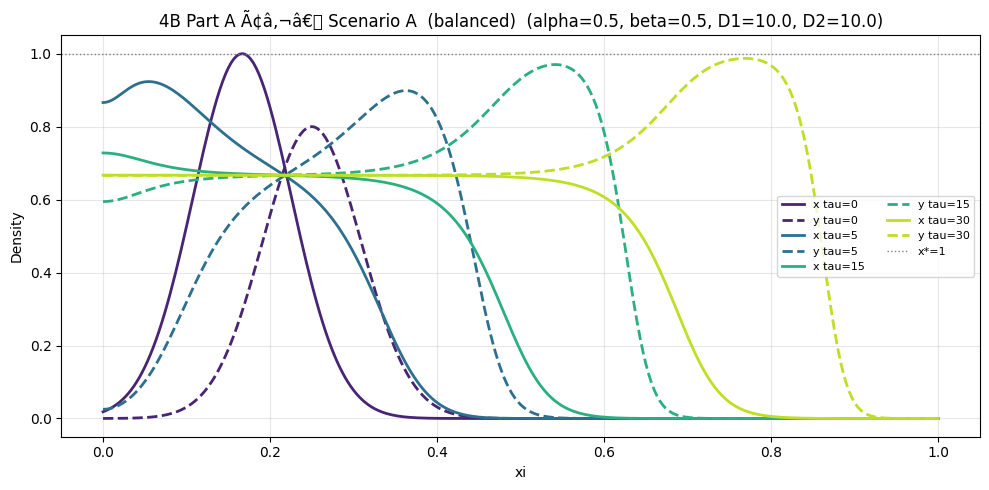

C:\Users\Bakri\AppData\Local\Temp\ipykernel_18424\316528000.py:66: UserWarning: Glyph 157 (\x9d) missing from font(s) DejaVu Sans.
  ax2.grid(True, alpha=0.3);  ax2.legend();  plt.tight_layout();  plt.show()


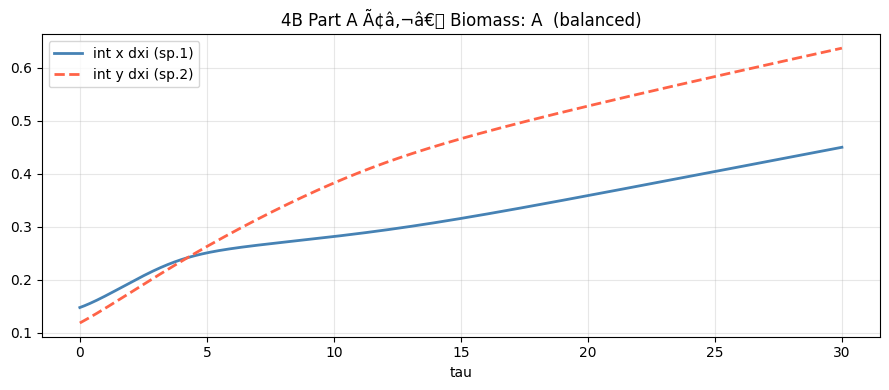

[B  (sp.1 dominates)] final x: min=0.0000 max=1.0000; y: min=0.0000 max=0.9546


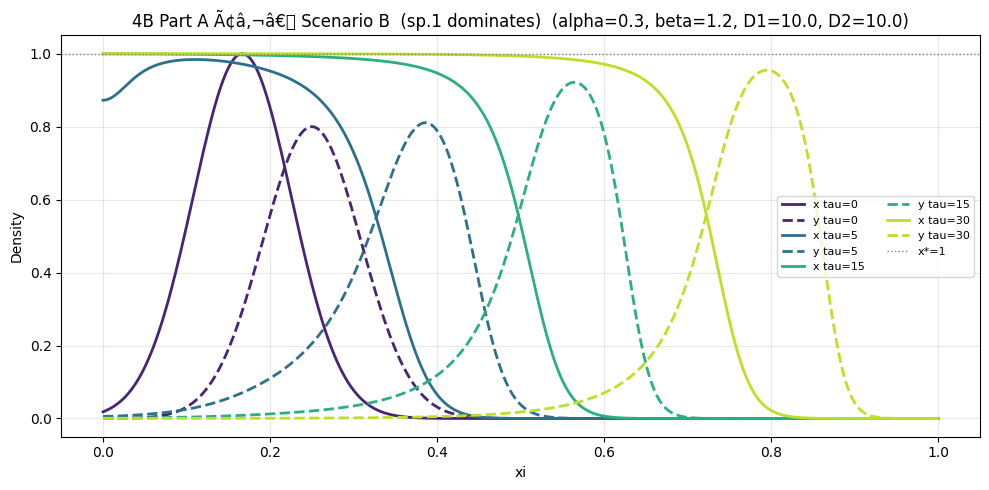

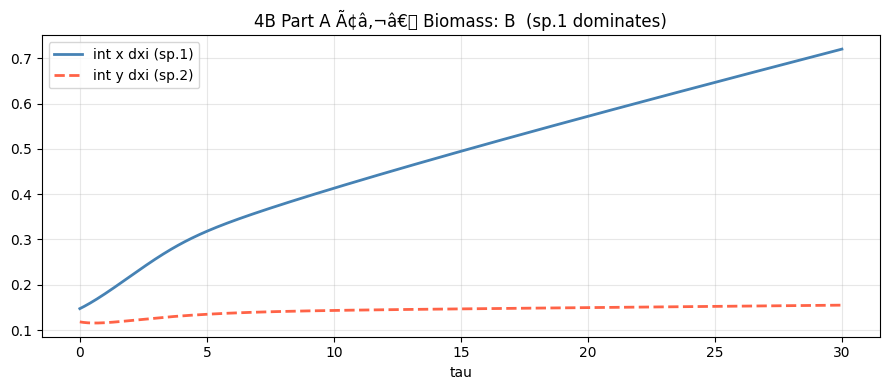

[C  (move. asym.)] final x: min=0.0000 max=0.6266; y: min=0.6235 max=1.0000


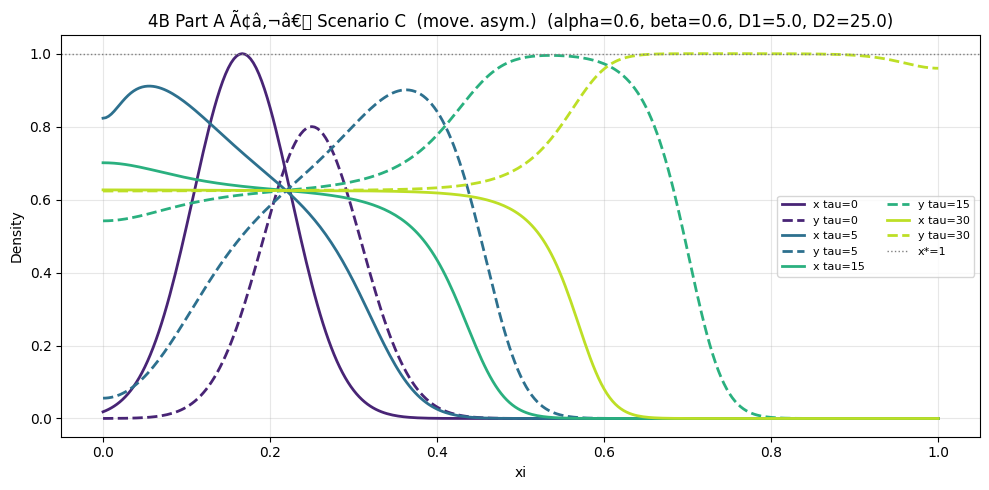

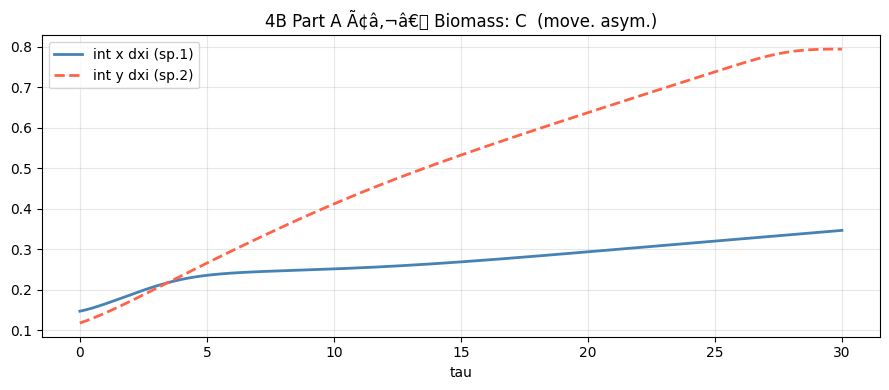

C:\Users\Bakri\AppData\Local\Temp\ipykernel_18424\316528000.py:99: UserWarning: Glyph 157 (\x9d) missing from font(s) DejaVu Sans.
  ax.grid(True, alpha=0.3);  ax.legend();  plt.tight_layout();  plt.show()


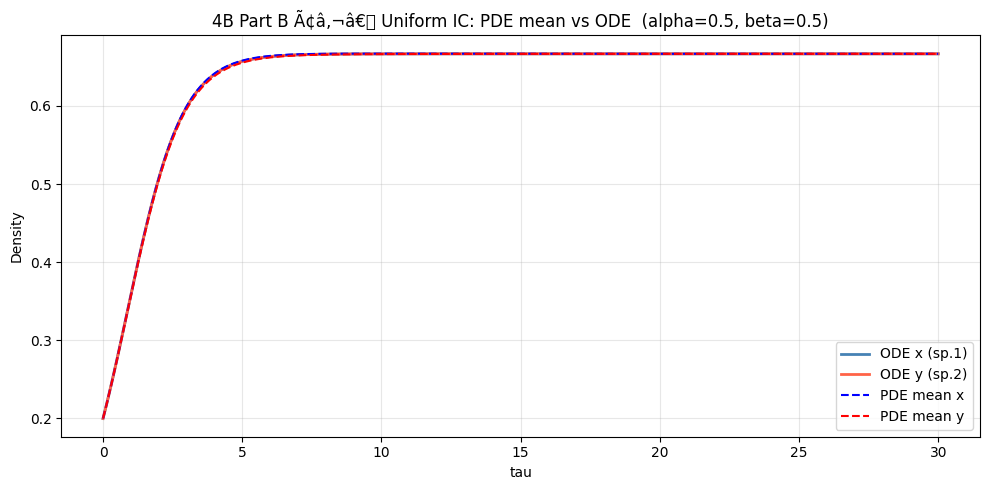

In [302]:
import numpy as np
from matplotlib import pyplot as plt
from pde_solver import laplacian_neumann

# Ã¢â€â‚¬Ã¢â€â‚¬ Grid / shared parameters Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬Ã¢â€â‚¬
L_rd_4b: float = 600.0;  N_rd_4b: int = 301
r1_4b: float = 0.5;      r2_4b: float = 0.5
K1_4b: float = 1.0;      K2_4b: float = 1.0
T_end_4b_dim: float = 60.0
dxi_4b = 1.0 / (N_rd_4b - 1)
tau_end_4b = r1_4b * T_end_4b_dim
xi_4b = np.linspace(0.0, 1.0, N_rd_4b)
xi_pk1_4b = 100.0 / L_rd_4b;  xi_pk2_4b = 150.0 / L_rd_4b;  sig_4b = 50.0 / L_rd_4b
x0_4b = np.exp(-((xi_4b - xi_pk1_4b) / sig_4b)**2)
y0_4b = 0.8 * np.exp(-((xi_4b - xi_pk2_4b) / sig_4b)**2)
snap_tau_4b = [0.0, 5.0, 15.0, 30.0]

SCENARIOS_4B = [
    dict(label='A  (balanced)',      alpha=0.5, beta=0.5, D1=10.0, D2=10.0),
    dict(label='B  (sp.1 dominates)',alpha=0.3, beta=1.2, D1=10.0, D2=10.0),
    dict(label='C  (move. asym.)',   alpha=0.6, beta=0.6, D1=5.0,  D2=25.0),
]

# =====================================================================
# Part A Ã¢â‚¬â€ Three competition scenarios
# =====================================================================
for scen in SCENARIOS_4B:
    alpha_s = scen['alpha'];  beta_s = scen['beta']
    D1_s = scen['D1'];        D2_s  = scen['D2'];  lbl = scen['label']
    rho_s  = r2_4b / r1_4b
    b12 = alpha_s * K2_4b / K1_4b;  b21 = beta_s * K1_4b / K2_4b
    d1  = D1_s / (r1_4b * L_rd_4b**2);  d2 = D2_s / (r1_4b * L_rd_4b**2)
    dtau = 0.45 * dxi_4b**2 / (2.0 * max(d1, d2))
    nt   = int(np.ceil(tau_end_4b / dtau));  dtau = tau_end_4b / nt
    x, y = x0_4b.copy(), y0_4b.copy()
    ssx, ssy = {}, {};  snap_set = set(snap_tau_4b)
    if 0.0 in snap_set: ssx[0.0]=x.copy(); ssy[0.0]=y.copy(); snap_set.discard(0.0)
    Bx = np.empty(nt+1); By = np.empty(nt+1); th = np.empty(nt+1)
    Bx[0] = np.trapezoid(x, xi_4b); By[0] = np.trapezoid(y, xi_4b); th[0] = 0.0
    warned4b = False
    for n in range(1, nt+1):
        lx = laplacian_neumann(x, dxi_4b);  ly = laplacian_neumann(y, dxi_4b)
        x = x + dtau*(x*(1.0-x-b12*y) + d1*lx)
        y = y + dtau*(rho_s*y*(1.0-y-b21*x) + d2*ly)
        if (x.min()<-1e-10 or y.min()<-1e-10) and not warned4b:
            print(f'  [{lbl}] WARNING negative at step {n} Ã¢â‚¬â€ clipping'); warned4b=True
        x=np.maximum(x,0.0); y=np.maximum(y,0.0)
        tau=n*dtau; Bx[n]=np.trapezoid(x,xi_4b); By[n]=np.trapezoid(y,xi_4b); th[n]=tau
        for ts in list(snap_set):
            if abs(tau-ts)<0.5*dtau: ssx[ts]=x.copy(); ssy[ts]=y.copy(); snap_set.discard(ts)
    print(f'[{lbl}] final x: min={x.min():.4f} max={x.max():.4f}; y: min={y.min():.4f} max={y.max():.4f}')
    clrs = plt.cm.viridis(np.linspace(0.1, 0.9, len(snap_tau_4b)))
    fig, ax = plt.subplots(figsize=(10, 5))
    for i, ts in enumerate(sorted(ssx)):
        ax.plot(xi_4b, ssx[ts], color=clrs[i], ls='-',  lw=2.0, label=f'x tau={ts:g}')
        ax.plot(xi_4b, ssy[ts], color=clrs[i], ls='--', lw=2.0, label=f'y tau={ts:g}')
    ax.axhline(1.0, color='grey', ls=':', lw=1.0, label='x*=1')
    ax.set_title(f'4B Part A Ã¢â‚¬â€ Scenario {lbl}  (alpha={alpha_s}, beta={beta_s}, D1={D1_s}, D2={D2_s})')
    ax.set_xlabel('xi');  ax.set_ylabel('Density')
    ax.grid(True, alpha=0.3);  ax.legend(fontsize=8, ncol=2)
    plt.tight_layout();  plt.show()
    fig2, ax2 = plt.subplots(figsize=(9, 4))
    ax2.plot(th, Bx, color='steelblue', lw=2.0, label='int x dxi (sp.1)')
    ax2.plot(th, By, color='tomato',    lw=2.0, ls='--', label='int y dxi (sp.2)')
    ax2.set_title(f'4B Part A Ã¢â‚¬â€ Biomass: {lbl}');  ax2.set_xlabel('tau')
    ax2.grid(True, alpha=0.3);  ax2.legend();  plt.tight_layout();  plt.show()

# =====================================================================
# Part B Ã¢â‚¬â€ Uniform IC validation
# =====================================================================
alpha_B=0.5; beta_B=0.5; D1_B=10.0; D2_B=10.0
rho_B=r2_4b/r1_4b; b12B=alpha_B*K2_4b/K1_4b; b21B=beta_B*K1_4b/K2_4b
d1B=D1_B/(r1_4b*L_rd_4b**2); d2B=D2_B/(r1_4b*L_rd_4b**2)
dtau_B=0.45*dxi_4b**2/(2.0*max(d1B,d2B))
nt_B=int(np.ceil(tau_end_4b/dtau_B)); dtau_B=tau_end_4b/nt_B
x0u=0.2; y0u=0.2
xB=x0u*np.ones(N_rd_4b); yB=y0u*np.ones(N_rd_4b)
mx=np.empty(nt_B+1); my=np.empty(nt_B+1); thB=np.empty(nt_B+1)
mx[0]=xB.mean(); my[0]=yB.mean(); thB[0]=0.0
for n in range(1,nt_B+1):
    lx=laplacian_neumann(xB,dxi_4b); ly=laplacian_neumann(yB,dxi_4b)
    xB=xB+dtau_B*(xB*(1.0-xB-b12B*yB)+d1B*lx)
    yB=yB+dtau_B*(rho_B*yB*(1.0-yB-b21B*xB)+d2B*ly)
    mx[n]=xB.mean(); my[n]=yB.mean(); thB[n]=n*dtau_B
xode=x0u; yode=y0u
xodeh=np.empty(nt_B+1); yodeh=np.empty(nt_B+1)
xodeh[0]=xode; yodeh[0]=yode
for n in range(1,nt_B+1):
    dx=xode*(1.0-xode-b12B*yode); dy=rho_B*yode*(1.0-yode-b21B*xode)
    xode+=dtau_B*dx; yode+=dtau_B*dy
    xodeh[n]=xode; yodeh[n]=yode
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thB, xodeh, 'steelblue',   lw=2.0, label='ODE x (sp.1)')
ax.plot(thB, yodeh, 'tomato',      lw=2.0, label='ODE y (sp.2)')
ax.plot(thB, mx,    'b--',         lw=1.5, label='PDE mean x')
ax.plot(thB, my,    'r--',         lw=1.5, label='PDE mean y')
ax.set_title('4B Part B Ã¢â‚¬â€ Uniform IC: PDE mean vs ODE  (alpha=0.5, beta=0.5)')
ax.set_xlabel('tau');  ax.set_ylabel('Density')
ax.grid(True, alpha=0.3);  ax.legend();  plt.tight_layout();  plt.show()

# 4C Ã¢â‚¬â€ Competing Species with Fishing Policy (200-mile EEZ Boundary)

Extends Ã‚Â§4B by adding proportional harvesting with an EEZ policy boundary at $s_{\rm bnd} = 200$ miles ($\xi_{\rm bnd} = 1/3$):

$$\frac{\partial x}{\partial \tau} = x(1 - x - \beta_{12}y) - \tilde{h}_1(\xi,\tau)\,x + \delta_1 x_{\xi\xi}$$
$$\frac{\partial y}{\partial \tau} = \rho\,y(1 - y - \beta_{21}x) - \tilde{h}_2(\xi,\tau)\,y + \delta_2 y_{\xi\xi}$$

The dimensionless fishing rate $\tilde{h}_i = h_i / r_1$ is piecewise-constant across the EEZ boundary, with the same MEY/MSY calibration as ?????????3C and the same yearly `h_MEY_4c` / `h_MSY_4c` schedules reused for both species in every harvested case.

### Policy scenarios

| Scenario | $\tilde{h}_{\rm in}$ (EEZ) | $\tilde{h}_{\rm out}$ (international) |
|----------|-----------------------------|------------------------------------------|
| A | 0 | 0 | No fishing (baseline, matches Ã‚Â§4B) |
| B | $\tilde{h}_{\rm MEY}$ | $\tilde{h}_{\rm MEY}$ | Uniform MEY both species |
| C | $\tilde{h}_{\rm MEY}$ | $\tilde{h}_{\rm MSY}$ | EEZ at MEY, international at MSY |

**Ã‚Â§4C(i):** $u$ centred at $s=100$, $v$ centred at $s=150$ (both inshore of the EEZ boundary).  
**Ã‚Â§4C(ii):** $u$ at $s=100$ (inside), $v$ at $s=400$ (outside EEZ).  
**Ã‚Â§4C(iii):** Both centred at $s=200$ (on boundary).

In [303]:
import importlib
import pde_solver, plotting
importlib.reload(pde_solver)
importlib.reload(plotting)
from pde_solver import simulate_competing_rd_fishing
from plotting  import (plot_snapshots_2s, plot_biomass_2s,
                        plot_biomass_comparison_2s,
                        plot_catch_2s, plot_heatmap_2s,
                        plot_3d_surface, plot_3d_surface_plotly, plot_heatmap)

In [304]:
import numpy as np
from matplotlib import pyplot as plt

L_4c: float = 600.0
N_4c: int = 301
D1_4c: float = 10.0
D2_4c: float = 10.0
r1_4c: float = 0.5
r2_4c: float = 0.5
K1_4c: float = 1.0
K2_4c: float = 1.0
alpha_4c: float = 0.5
beta_4c: float = 0.5
harvest_duration_4c: float = 60.0
S_BND_4c: float = 200.0
n_tau_years_4c: int = int(np.ceil(r1_4c * harvest_duration_4c))

EQ_REL_TOL_4C: float = 0.02
EQ_STREAK_4C: int = 3
EQ_SCAN_START_4C: float = 120.0
EQ_SCAN_STEP_4C: float = 60.0
EQ_SCAN_MAX_4C: float = 600.0

delta1_4c = D1_4c / (r1_4c * L_4c**2)
delta2_4c = D2_4c / (r1_4c * L_4c**2)
xi_bnd_4c = S_BND_4c / L_4c
u_star_4c = (K1_4c - alpha_4c * K2_4c) / (1.0 - alpha_4c * beta_4c)
v_star_4c = (K2_4c - beta_4c * K1_4c) / (1.0 - alpha_4c * beta_4c)

print(f"delta1={delta1_4c:.3e}, delta2={delta2_4c:.3e}, xi_bnd={xi_bnd_4c:.4f}")
print(f"Two-species coexistence steady state: u*={u_star_4c:.4f}, v*={v_star_4c:.4f}")


def build_phase_snapshots_4c(warmup: float, harvest_duration: float, total_duration: float) -> list[float]:
    snaps = [
        0.0,
        0.5 * warmup,
        warmup,
        warmup + 0.25 * harvest_duration,
        warmup + 0.5 * harvest_duration,
        total_duration,
    ]
    ordered: list[float] = []
    for value in snaps:
        value = float(value)
        if not ordered or abs(value - ordered[-1]) > 1e-9:
            ordered.append(value)
    return ordered


def delayed_schedule_pulse_xy_4c(
    schedule_arr: np.ndarray,
    start_time: float,
    r_scale: float,
) -> tuple[np.ndarray, np.ndarray]:
    schedule_arr = np.asarray(schedule_arr, dtype=float)
    if schedule_arr.size == 0:
        raise ValueError("schedule_arr must not be empty")
    if r_scale <= 0.0:
        raise ValueError("r_scale must be positive")
    tau_step_in_time = 1.0 / r_scale
    pulse_times = start_time + tau_step_in_time * np.arange(schedule_arr.size, dtype=float)
    return pulse_times, schedule_arr.copy()


def first_profile_equilibrium_time_2s(
    t_full: np.ndarray,
    u_full: np.ndarray,
    v_full: np.ndarray,
    u_target: np.ndarray,
    v_target: np.ndarray,
    rel_tol: float = EQ_REL_TOL_4C,
    streak: int = EQ_STREAK_4C,
) -> float | None:
    scale_u = max(float(np.max(np.abs(u_target))), 1e-12)
    scale_v = max(float(np.max(np.abs(v_target))), 1e-12)
    err_u = np.max(np.abs(u_full - u_target[None, :]), axis=1) / scale_u
    err_v = np.max(np.abs(v_full - v_target[None, :]), axis=1) / scale_v
    combined_err = np.maximum(err_u, err_v)
    consecutive = 0
    for t_now, err in zip(t_full, combined_err):
        consecutive = consecutive + 1 if err <= rel_tol else 0
        if consecutive >= streak:
            return float(t_now)
    return None


def estimate_warmup_4c(placements: list[tuple[float, float]]) -> tuple[float, dict[tuple[float, float], float], float]:
    u_target = np.full(N_4c, u_star_4c)
    v_target = np.full(N_4c, v_star_4c)
    scan_end = EQ_SCAN_START_4C
    while scan_end <= EQ_SCAN_MAX_4C:
        dense_frames = max(600, int(np.ceil(5.0 * scan_end)))
        eq_times: dict[tuple[float, float], float] = {}
        for u_center, v_center in placements:
            ref = simulate_competing_rd_fishing(
                L=L_4c,
                N=N_4c,
                D1=D1_4c,
                D2=D2_4c,
                r1=r1_4c,
                r2=r2_4c,
                K1=K1_4c,
                K2=K2_4c,
                alpha=alpha_4c,
                beta=beta_4c,
                T_end=scan_end,
                s_boundary=S_BND_4c,
                h1_in=0.0,
                h1_out=0.0,
                h2_in=0.0,
                h2_out=0.0,
                u0_gaussian_center=u_center,
                u0_gaussian_scale=50.0,
                v0_gaussian_center=v_center,
                v0_gaussian_scale=60.0,
                store_full=True,
                full_n_frames=dense_frames,
            )
            eq_time = first_profile_equilibrium_time_2s(
                ref["t_full"],
                ref["u_full"],
                ref["v_full"],
                u_target,
                v_target,
            )
            if eq_time is not None:
                eq_times[(u_center, v_center)] = eq_time
        if len(eq_times) == len(placements):
            return max(eq_times.values()), eq_times, scan_end
        scan_end += EQ_SCAN_STEP_4C
    raise RuntimeError(
        f"4C warm-up did not reach equilibrium within {EQ_SCAN_MAX_4C:.1f} years."
    )


placements_4c = [(100.0, 150.0), (100.0, 400.0), (200.0, 200.0)]
estimated_warmup_4c, eq_times_4c, warmup_scan_4c = estimate_warmup_4c(placements_4c)
tau_harvest_start_4c: float = 10.0
warmup_4c: float = tau_harvest_start_4c / r1_4c
T_total_4c: float = warmup_4c + harvest_duration_4c
snapshot_times_4c = build_phase_snapshots_4c(warmup_4c, harvest_duration_4c, T_total_4c)

print(
    "4C equilibrium times by initial placement (years):",
    {
        f"u{int(u_center)}_v{int(v_center)}": round(eq_time, 2)
        for (u_center, v_center), eq_time in sorted(eq_times_4c.items())
    },
)
print(
    f"4C estimated equilibrium warm-up = {estimated_warmup_4c:.2f} years; "
    f"using fixed harvest start at t={warmup_4c:.2f} years (tau = {tau_harvest_start_4c:.2f})"
)
print(f"4C total simulated time = {T_total_4c:.2f} years")

np.random.seed(42)
MEY_frac_4c = np.random.uniform(0.80, 0.90, size=n_tau_years_4c)
h_tilde_MEY_4c = (1.0 - np.sqrt(1.0 - MEY_frac_4c)) / 2.0
h_tilde_MSY_4c = 0.5 * np.random.uniform(0.90, 1.10, size=n_tau_years_4c)
h_MEY_4c = h_tilde_MEY_4c * r1_4c
h_MSY_4c = h_tilde_MSY_4c * r1_4c

print(f"h_tilde_MEY mean={h_tilde_MEY_4c.mean():.4f}")
print(f"h_tilde_MSY mean={h_tilde_MSY_4c.mean():.4f}")

SCENARIOS_4C = {
    "A": dict(
        label="No Fishing (Baseline)",
        h1_in=0.0,
        h1_out=0.0,
        h2_in=0.0,
        h2_out=0.0,
        h1_in_schedule=None,
        h1_out_schedule=None,
        h2_in_schedule=None,
        h2_out_schedule=None,
    ),
    "B": dict(
        label=f"Uniform MEY both species (mean h_tilde={h_tilde_MEY_4c.mean():.3f})",
        h1_in=h_MEY_4c.mean(),
        h1_out=h_MEY_4c.mean(),
        h2_in=h_MEY_4c.mean(),
        h2_out=h_MEY_4c.mean(),
        h1_in_schedule=h_MEY_4c,
        h1_out_schedule=h_MEY_4c,
        h2_in_schedule=h_MEY_4c,
        h2_out_schedule=h_MEY_4c,
    ),
    "C": dict(
        label=(
            "EEZ at MEY, international at MSY "
            f"(MEY h_t={h_tilde_MEY_4c.mean():.3f}, MSY h_t={h_tilde_MSY_4c.mean():.3f})"
        ),
        h1_in=h_MEY_4c.mean(),
        h1_out=h_MSY_4c.mean(),
        h2_in=h_MEY_4c.mean(),
        h2_out=h_MSY_4c.mean(),
        h1_in_schedule=h_MEY_4c,
        h1_out_schedule=h_MSY_4c,
        h2_in_schedule=h_MEY_4c,
        h2_out_schedule=h_MSY_4c,
    ),
}


def to_nd_2s(res: dict, L: float, r1: float, K1: float, K2: float) -> dict:
    nd = {
        "s": res["s"] / L,
        "time": res["time"] * r1,
        "snapshots_u": {t * r1: snap / K1 for t, snap in res["snapshots_u"].items()},
        "snapshots_v": {t * r1: snap / K2 for t, snap in res["snapshots_v"].items()},
        "B1_in": res["B1_in"] / (K1 * L),
        "B1_out": res["B1_out"] / (K1 * L),
        "B1_tot": res["B1_tot"] / (K1 * L),
        "B2_in": res["B2_in"] / (K2 * L),
        "B2_out": res["B2_out"] / (K2 * L),
        "B2_tot": res["B2_tot"] / (K2 * L),
        "Catch1": res["Catch1"] / (r1 * K1 * L),
        "CumCatch1": res["CumCatch1"] / (K1 * L),
        "Catch2": res["Catch2"] / (r1 * K2 * L),
        "CumCatch2": res["CumCatch2"] / (K2 * L),
        "s_boundary": res["s_boundary"] / L,
        "min_u": res["min_u"] / K1,
        "min_v": res["min_v"] / K2,
        "harvest_start_time": res.get("harvest_start_time", 0.0) * r1,
    }
    if "u_full" in res:
        nd["u_full"] = res["u_full"] / K1
        nd["v_full"] = res["v_full"] / K2
        nd["t_full"] = res["t_full"] * r1
    return nd


results_4c: dict = {}
full_frames_4c = max(300, int(np.ceil(4.0 * T_total_4c)))
for key, scen in SCENARIOS_4C.items():
    res = simulate_competing_rd_fishing(
        L=L_4c,
        N=N_4c,
        D1=D1_4c,
        D2=D2_4c,
        r1=r1_4c,
        r2=r2_4c,
        K1=K1_4c,
        K2=K2_4c,
        alpha=alpha_4c,
        beta=beta_4c,
        T_end=T_total_4c,
        s_boundary=S_BND_4c,
        h1_in=scen["h1_in"],
        h1_out=scen["h1_out"],
        h2_in=scen["h2_in"],
        h2_out=scen["h2_out"],
        h1_in_schedule=scen["h1_in_schedule"],
        h1_out_schedule=scen["h1_out_schedule"],
        h2_in_schedule=scen["h2_in_schedule"],
        h2_out_schedule=scen["h2_out_schedule"],
        u0_gaussian_center=100.0,
        u0_gaussian_scale=50.0,
        v0_gaussian_center=150.0,
        v0_gaussian_scale=60.0,
        snapshot_times=snapshot_times_4c,
        store_full=True,
        full_n_frames=full_frames_4c,
        harvest_start_time=warmup_4c,
    )
    results_4c[key] = res
    print(f"4C Scenario {key}: min_u={res['min_u']:.3e}, min_v={res['min_v']:.3e}")

results_4c_nd = {k: to_nd_2s(v, L_4c, r1_4c, K1_4c, K2_4c) for k, v in results_4c.items()}


delta1=5.556e-05, delta2=5.556e-05, xi_bnd=0.3333
Two-species coexistence steady state: u*=0.6667, v*=0.6667
4C equilibrium times by initial placement (years): {'u100_v150': 135.36, 'u100_v400': 148.32, 'u200_v200': 94.5}
4C estimated equilibrium warm-up = 148.32 years; using fixed harvest start at t=20.00 years (tau = 10.00)
4C total simulated time = 80.00 years
h_tilde_MEY mean=0.3032
h_tilde_MSY mean=0.4996
4C Scenario A: min_u=3.720e-44, min_v=2.979e-25
4C Scenario B: min_u=3.720e-44, min_v=2.979e-25
4C Scenario C: min_u=3.720e-44, min_v=2.979e-25


c:\Users\Bakri\OneDrive - Loughborough University\Masters Year\modelling2\Coding\plotting.py:887: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.


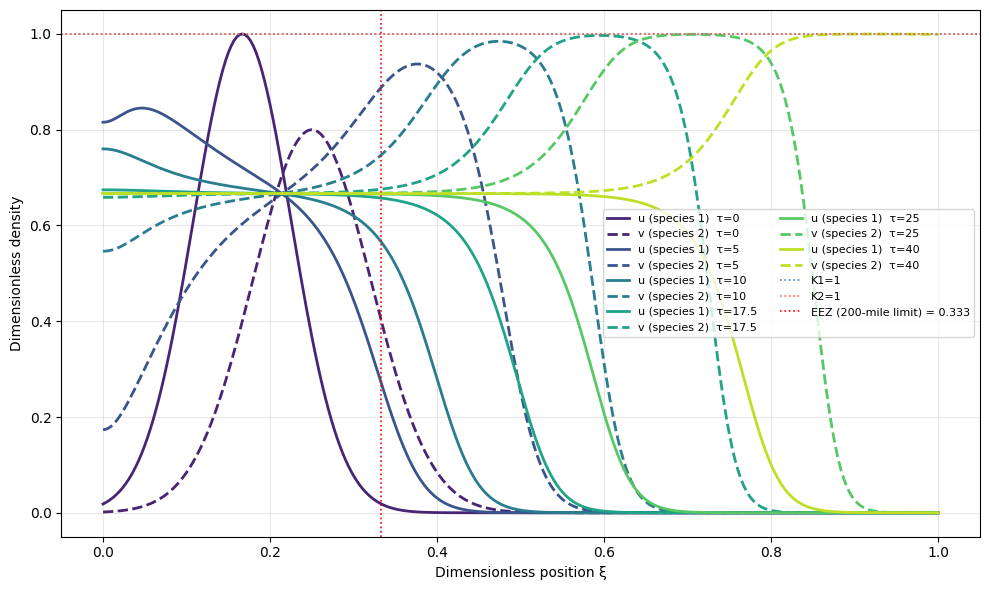

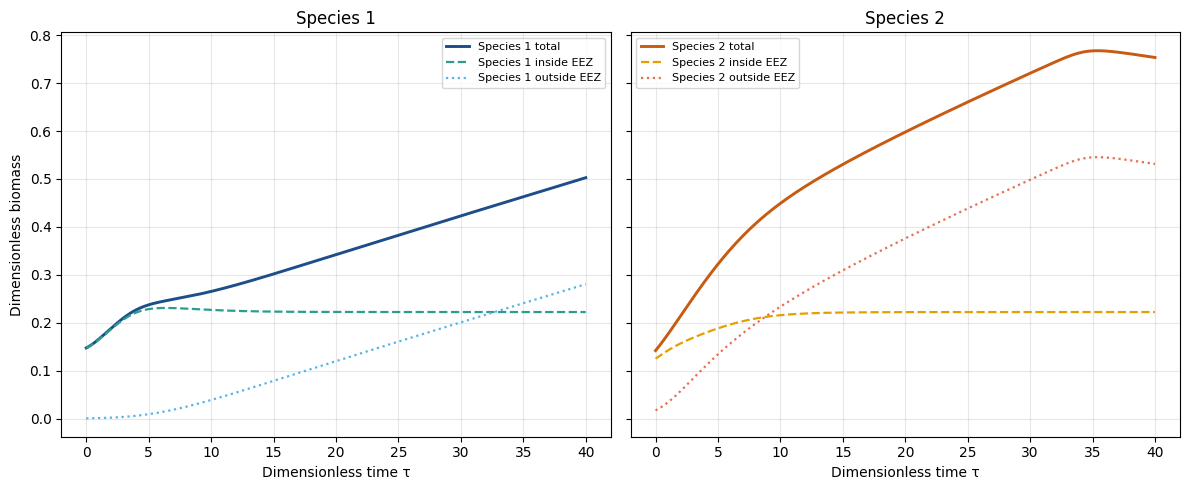

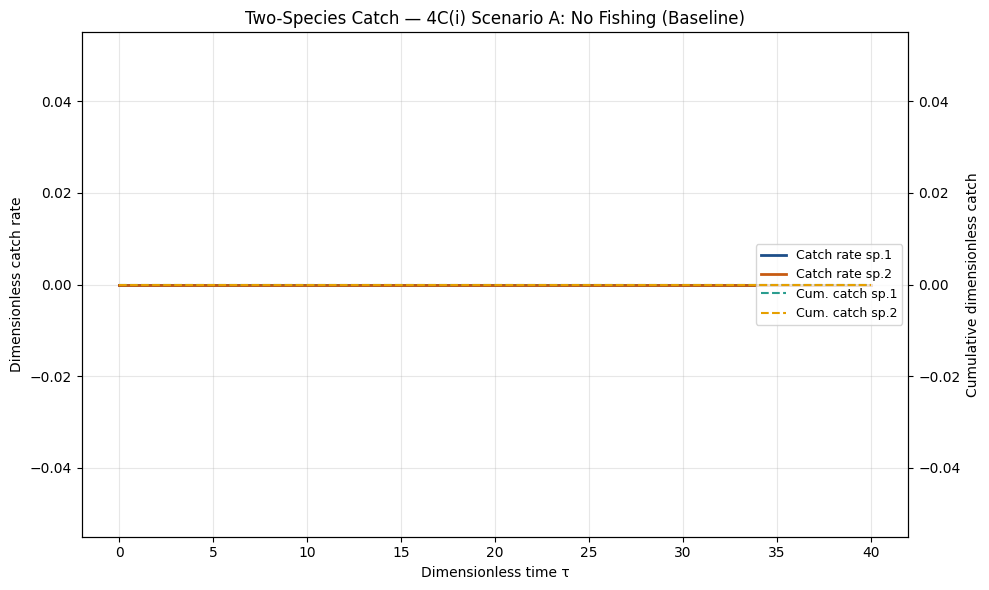

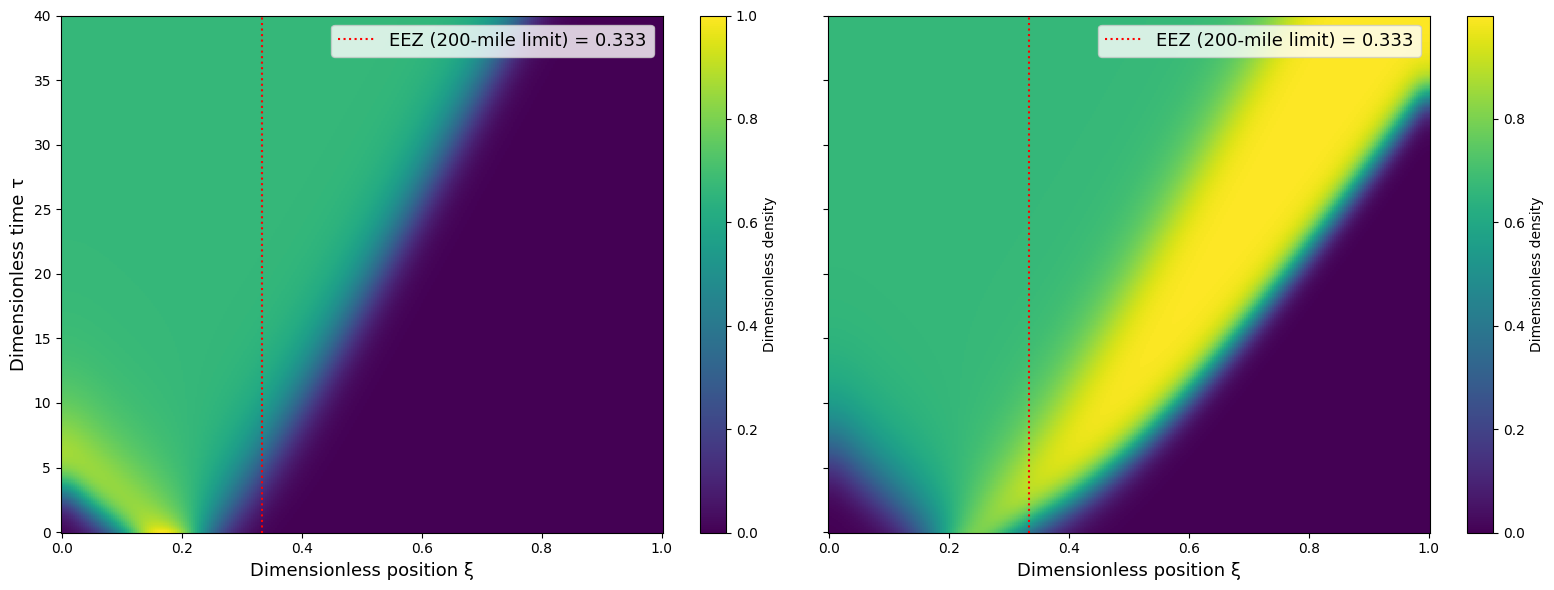

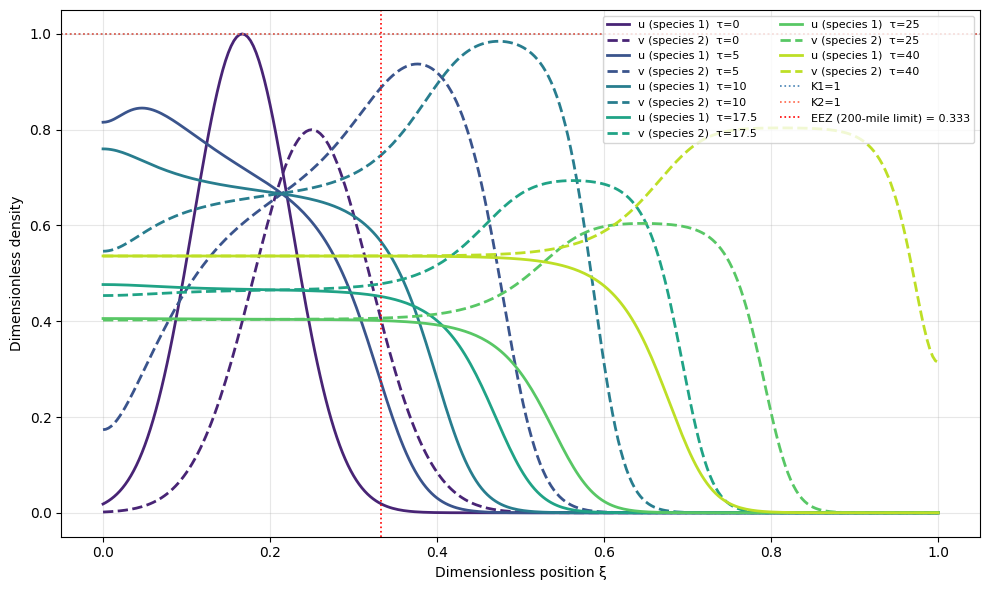

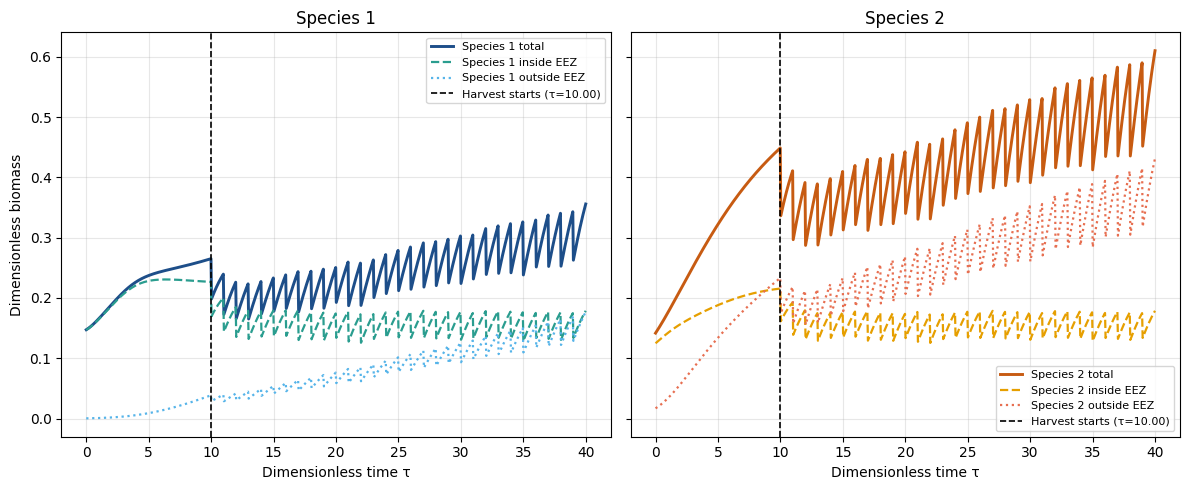

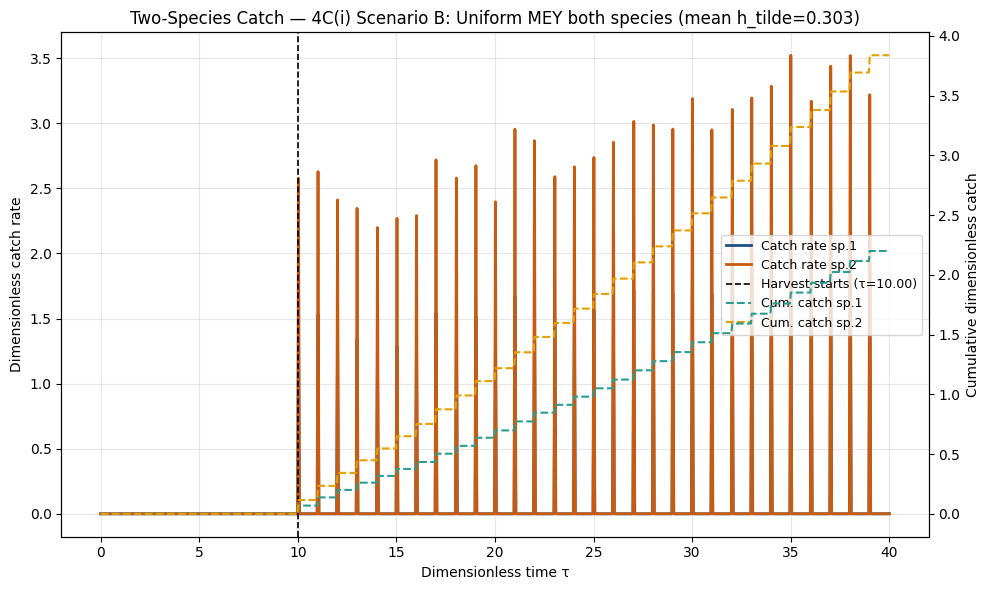

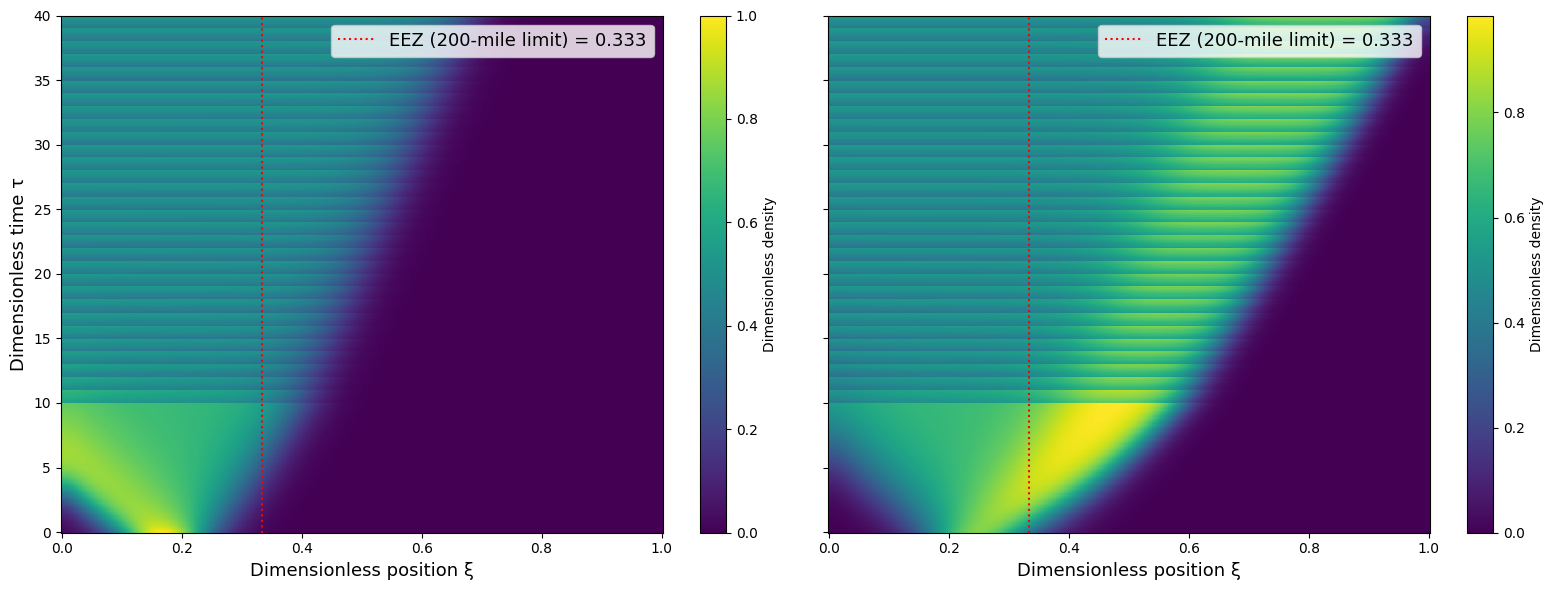

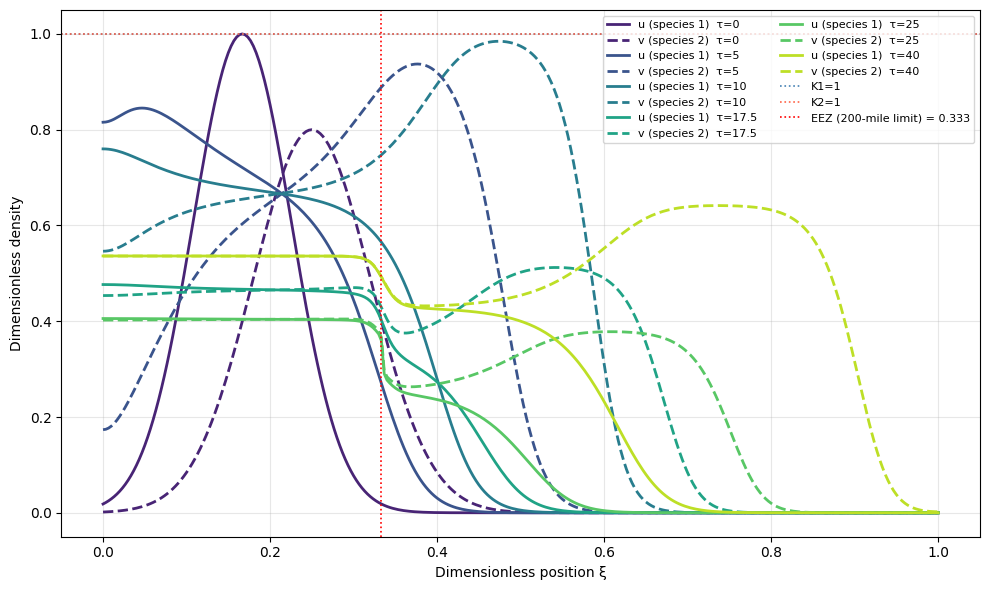

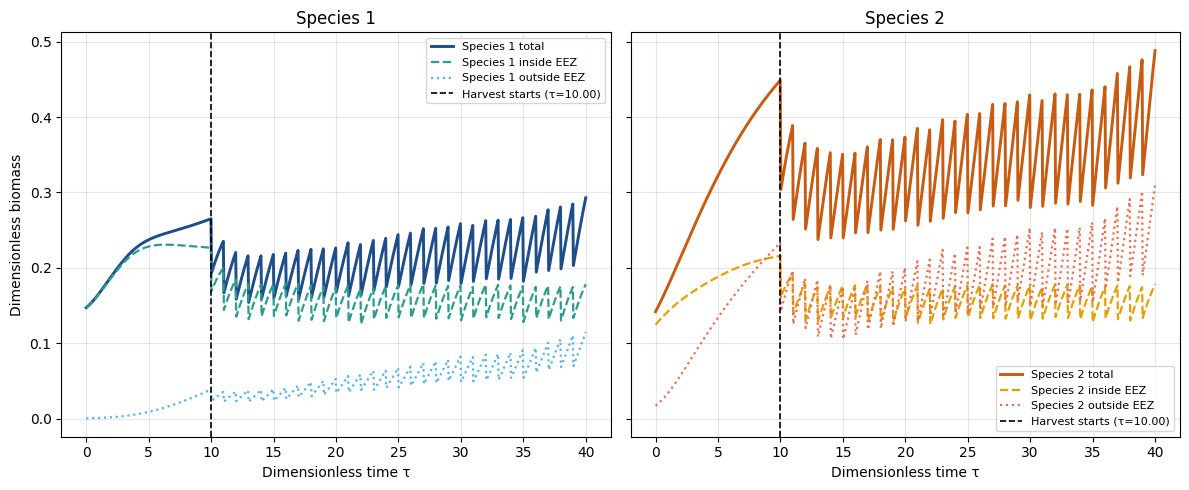

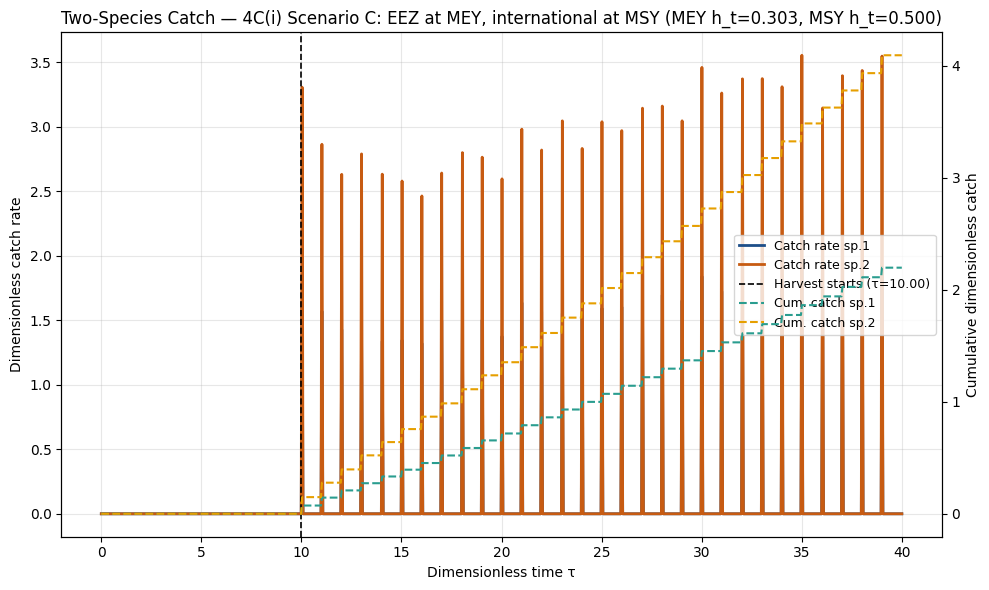

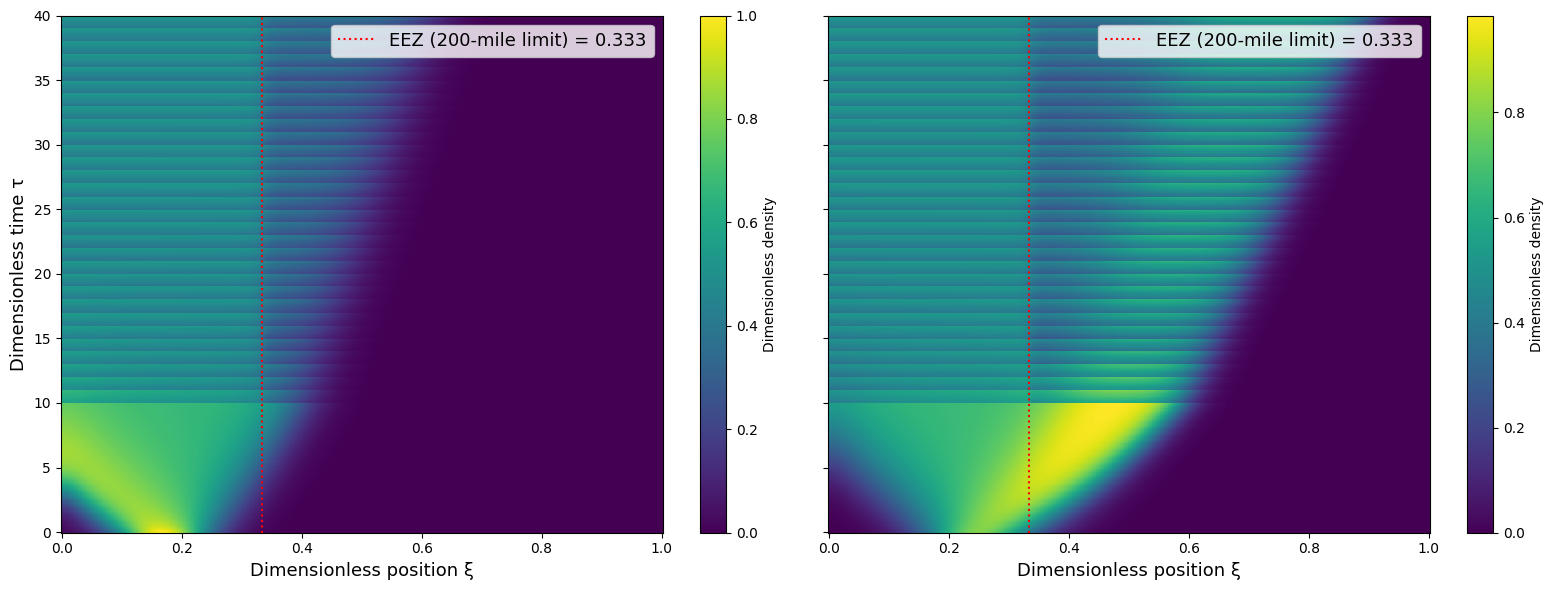

In [305]:
from matplotlib import pyplot as plt
from plotting import plot_snapshots_2s, plot_biomass_2s, plot_catch_2s, plot_heatmap_2s
# from plotting import plot_3d_surface, plot_3d_surface_plotly

for key, scen in SCENARIOS_4C.items():
    res_nd = results_4c_nd[key]
    tag = f'4C(i) Scenario {key}: {scen["label"]}'
    plot_snapshots_2s(res_nd, tag, K1=K1_4c, K2=K2_4c)
    plot_biomass_2s(res_nd, tag)
    plot_catch_2s(res_nd, tag)
    plot_heatmap_2s(res_nd, tag)
    # plot_3d_surface(res_nd['s'], res_nd['t_full'], res_nd['u_full'],
    #                 f'{tag}  [u, sp.1]', res_nd['s_boundary'])
    # plot_3d_surface(res_nd['s'], res_nd['t_full'], res_nd['v_full'],
    #                 f'{tag}  [v, sp.2]', res_nd['s_boundary'])
    plt.show()

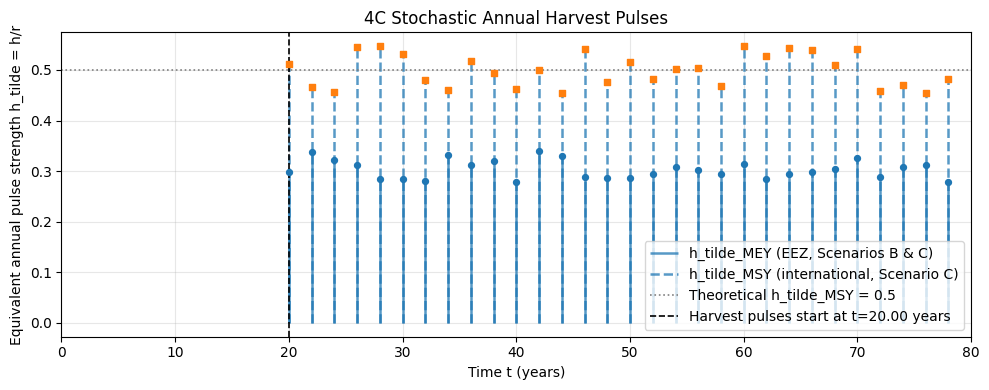

In [306]:
years_4c_mey, rates_4c_mey = delayed_schedule_pulse_xy_4c(h_tilde_MEY_4c, warmup_4c, r1_4c)
years_4c_msy, rates_4c_msy = delayed_schedule_pulse_xy_4c(h_tilde_MSY_4c, warmup_4c, r1_4c)

fig, ax = plt.subplots(figsize=(10, 4))
ax.vlines(
    years_4c_mey,
    0.0,
    rates_4c_mey,
    lw=1.8,
    alpha=0.75,
    label="h_tilde_MEY (EEZ, Scenarios B & C)",
)
ax.scatter(years_4c_mey, rates_4c_mey, s=18, zorder=3)
ax.vlines(
    years_4c_msy,
    0.0,
    rates_4c_msy,
    lw=1.8,
    linestyles="--",
    alpha=0.75,
    label="h_tilde_MSY (international, Scenario C)",
)
ax.scatter(years_4c_msy, rates_4c_msy, s=18, marker="s", zorder=3)
ax.axhline(0.5, color="grey", ls=":", lw=1.2, label="Theoretical h_tilde_MSY = 0.5")
ax.axvline(
    warmup_4c,
    color="black",
    linestyle="--",
    linewidth=1.2,
    label=f"Harvest pulses start at t={warmup_4c:.2f} years",
)
ax.set_xlim(0.0, T_total_4c)
ax.set_xlabel("Time t (years)")
ax.set_ylabel("Equivalent annual pulse strength h_tilde = h/r")
ax.set_title("4C Stochastic Annual Harvest Pulses")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 4C (ii) Ã¢â‚¬â€ Species Starting in Different Zones

Same Scenario C fishing policy (MEY inside EEZ, MSY in international waters), but species 2 ($v$) now starts **outside the EEZ** at $s = 400$ miles ($\xi_0 = 2/3$), while species 1 ($u$) remains at $s = 150$ miles. The same yearly `h_MEY_4c` / `h_MSY_4c` schedules are reused for both species.

This tests:
- Whether the long-run equilibrium is **robust to initial placement** of each species.
- How interspecies competition interacts with the fishing gradient when the two species begin in zones of different harvest pressure.
- Compare biomass dynamics against Ã‚Â§4C(i) where $v$ started near the boundary.

4C(ii) min_u=3.720e-44, min_v=3.991e-20; harvest starts at t=20.00 years


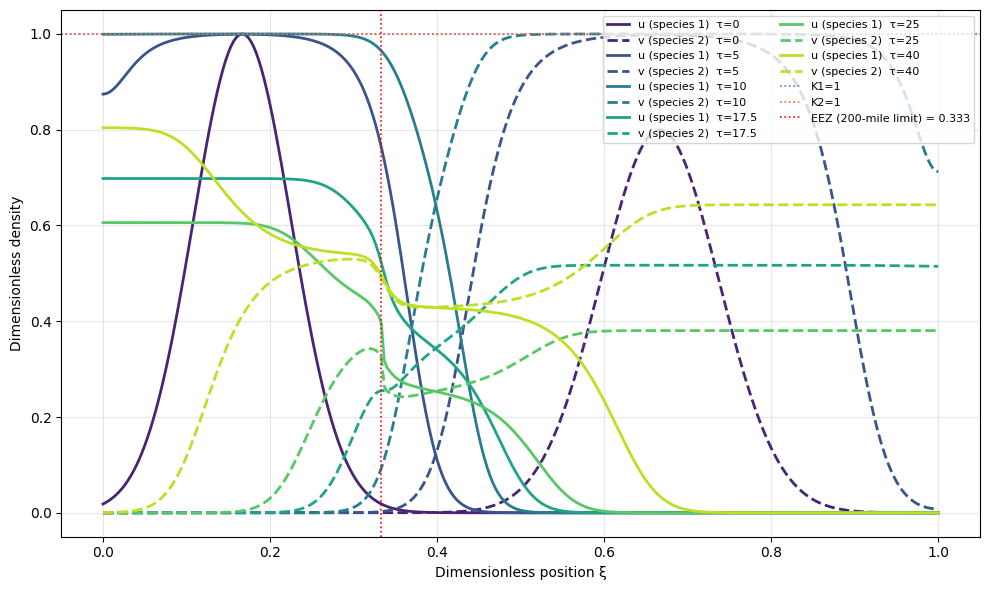

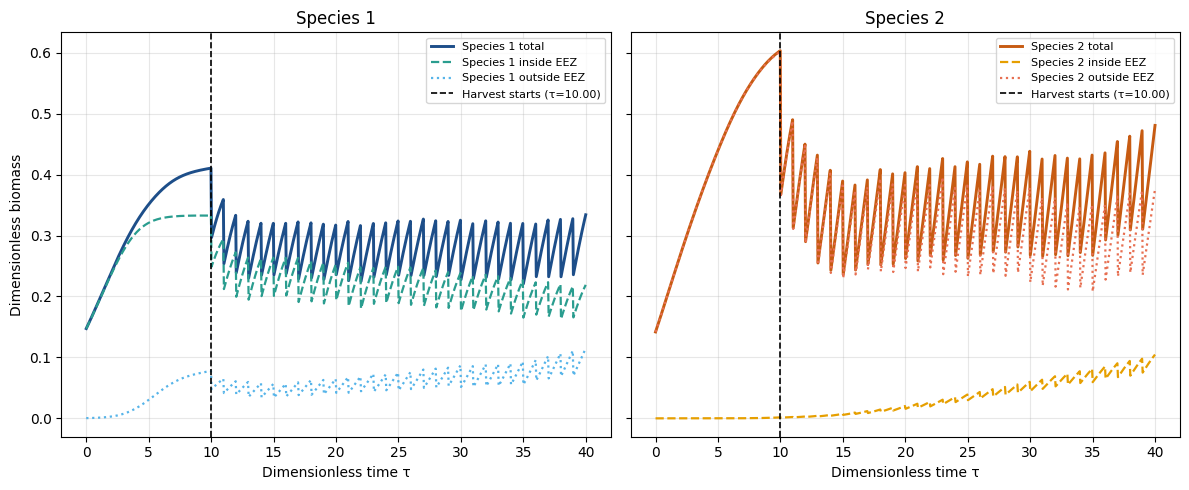

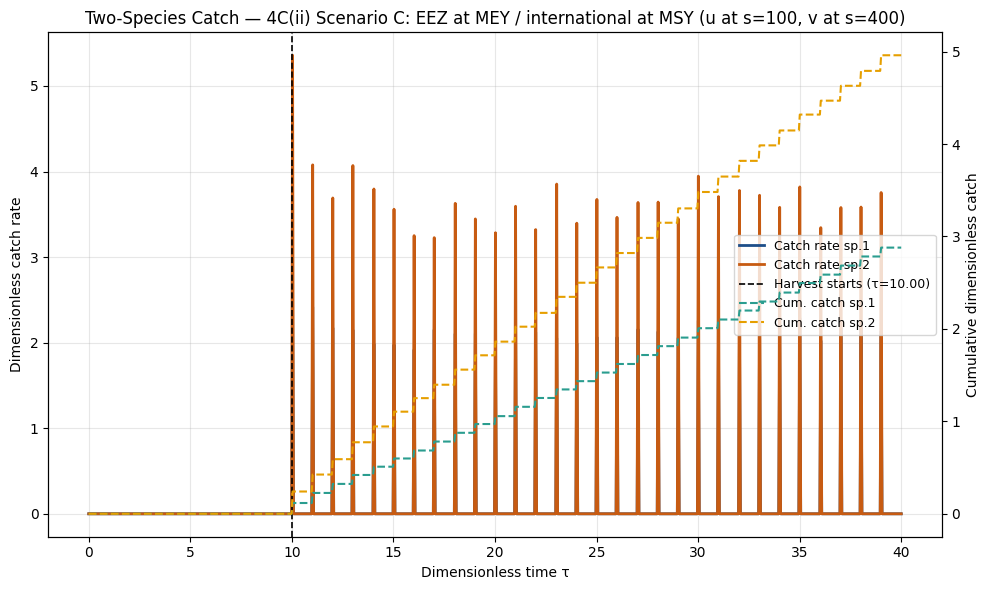

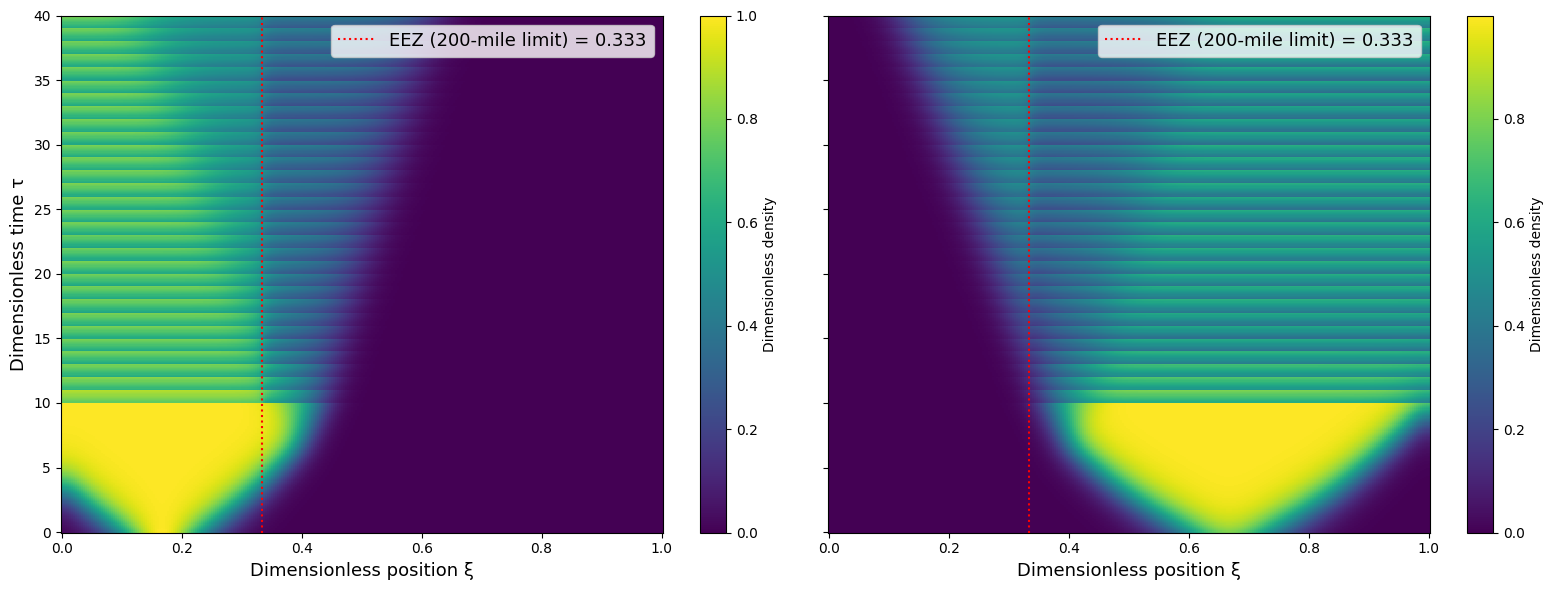

In [307]:
from matplotlib import pyplot as plt

res_Cii = simulate_competing_rd_fishing(
    L=L_4c,
    N=N_4c,
    D1=D1_4c,
    D2=D2_4c,
    r1=r1_4c,
    r2=r2_4c,
    K1=K1_4c,
    K2=K2_4c,
    alpha=alpha_4c,
    beta=beta_4c,
    T_end=T_total_4c,
    s_boundary=S_BND_4c,
    h1_in=h_MEY_4c.mean(),
    h1_out=h_MSY_4c.mean(),
    h2_in=h_MEY_4c.mean(),
    h2_out=h_MSY_4c.mean(),
    h1_in_schedule=h_MEY_4c,
    h1_out_schedule=h_MSY_4c,
    h2_in_schedule=h_MEY_4c,
    h2_out_schedule=h_MSY_4c,
    u0_gaussian_center=100.0,
    u0_gaussian_scale=50.0,
    v0_gaussian_center=400.0,
    v0_gaussian_scale=60.0,
    snapshot_times=snapshot_times_4c,
    store_full=True,
    full_n_frames=full_frames_4c,
    harvest_start_time=warmup_4c,
)
res_Cii_nd = to_nd_2s(res_Cii, L_4c, r1_4c, K1_4c, K2_4c)
tag_Cii = "4C(ii) Scenario C: EEZ at MEY / international at MSY (u at s=100, v at s=400)"
print(
    f"4C(ii) min_u={res_Cii['min_u']:.3e}, min_v={res_Cii['min_v']:.3e}; "
    f"harvest starts at t={warmup_4c:.2f} years"
)

plot_snapshots_2s(res_Cii_nd, tag_Cii, K1=K1_4c, K2=K2_4c)
plot_biomass_2s(res_Cii_nd, tag_Cii)
plot_catch_2s(res_Cii_nd, tag_Cii)
plot_heatmap_2s(res_Cii_nd, tag_Cii)
plt.show()


## 4C (iii) Ã¢â‚¬â€ Both Species Starting at the Boundary

Same Scenario C policy, but **both** species initialised with Gaussians centred at $s = 200$ miles ?????????????????? exactly on the EEZ boundary ($\xi_0 = 1/3$), again reusing the same yearly `h_MEY_4c` / `h_MSY_4c` schedules for both species.

This tests:
- How symmetric initial placement interacts with asymmetric fishing pressure.
- Whether both species diffuse preferentially inshore (lower pressure) or offshore.
- Comparison of all three sub-cases confirms the long-run attractor is independent of initial placement (robust equilibrium).

### 4C Scenario C - Effect of Initial Placement on Both Species Biomass

(same yearly MEY/MSY harvest schedules, with harvest starting at tau = 10)


4C(iii) min_u=1.604e-28, min_v=3.991e-20; harvest starts at t=20.00 years


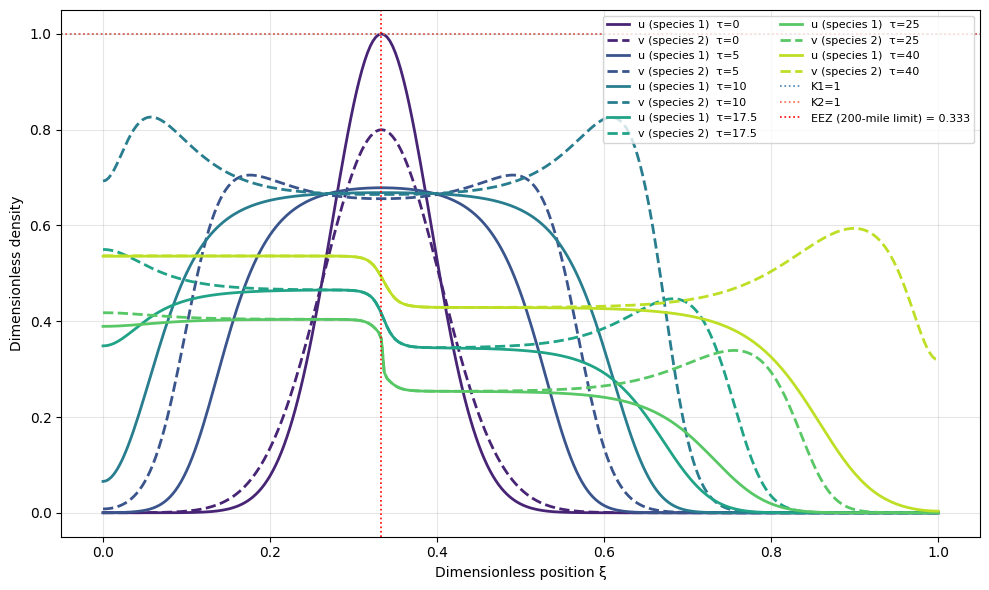

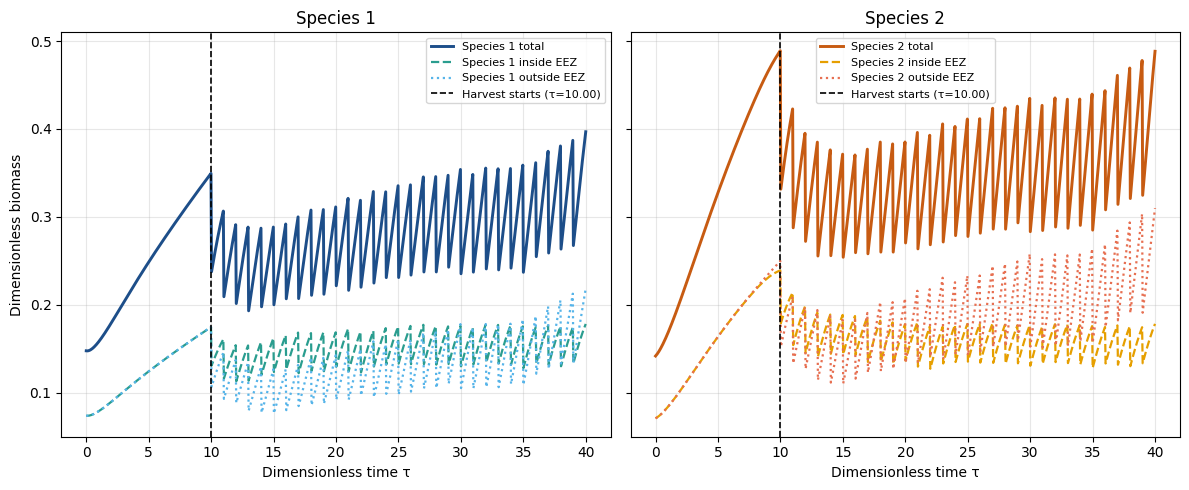

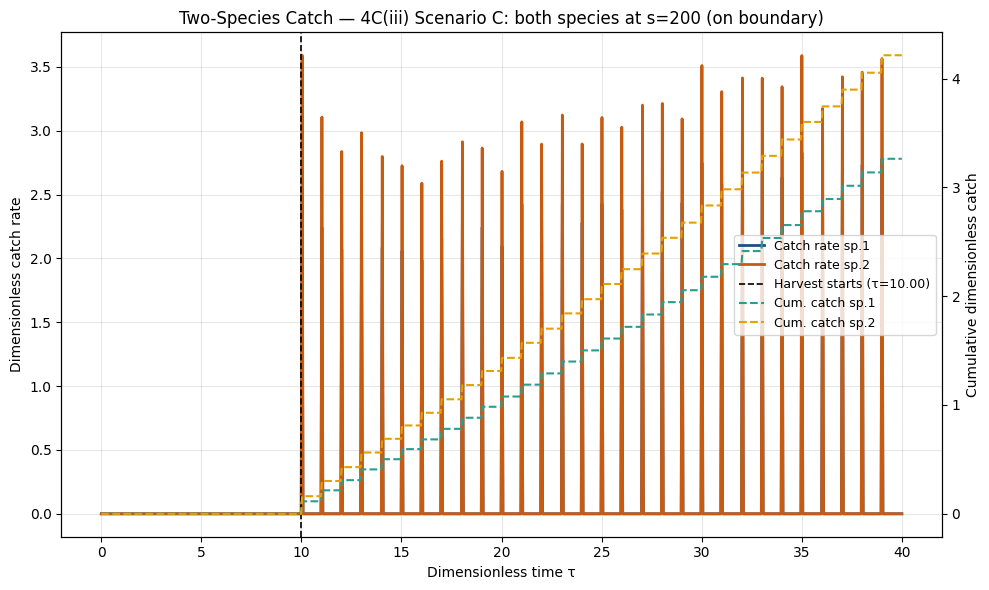

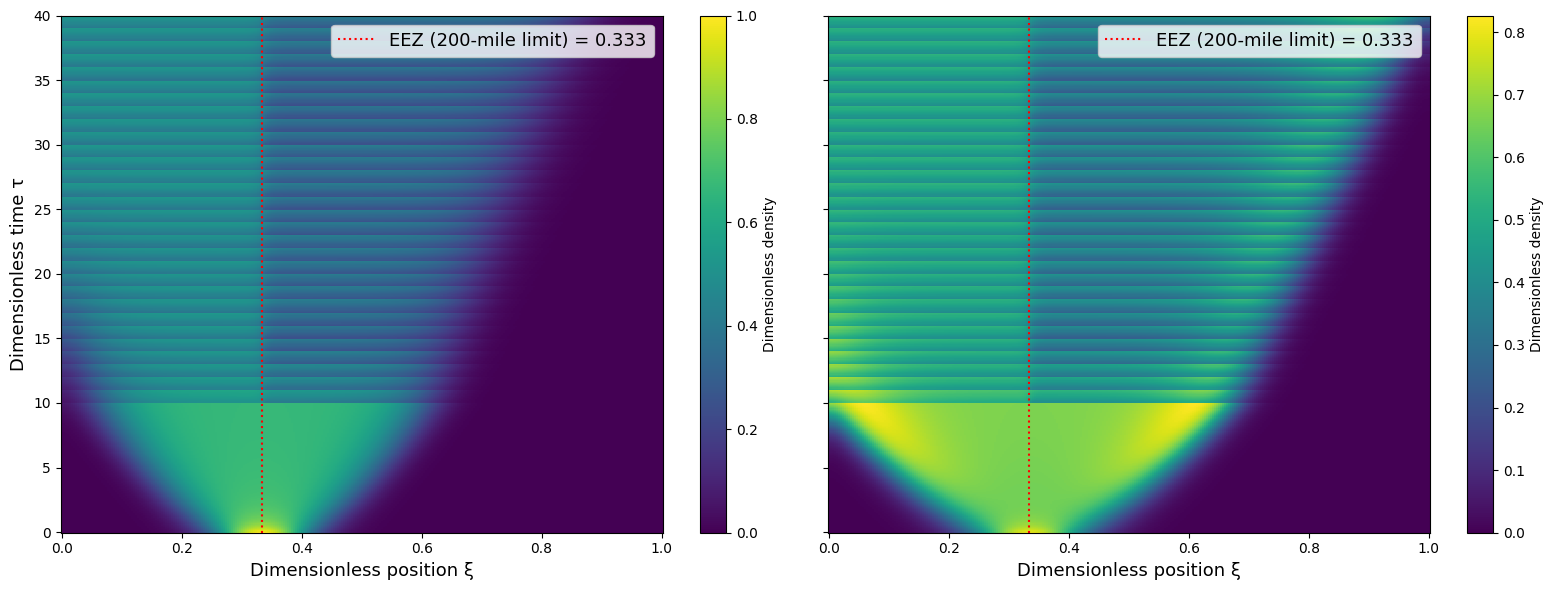

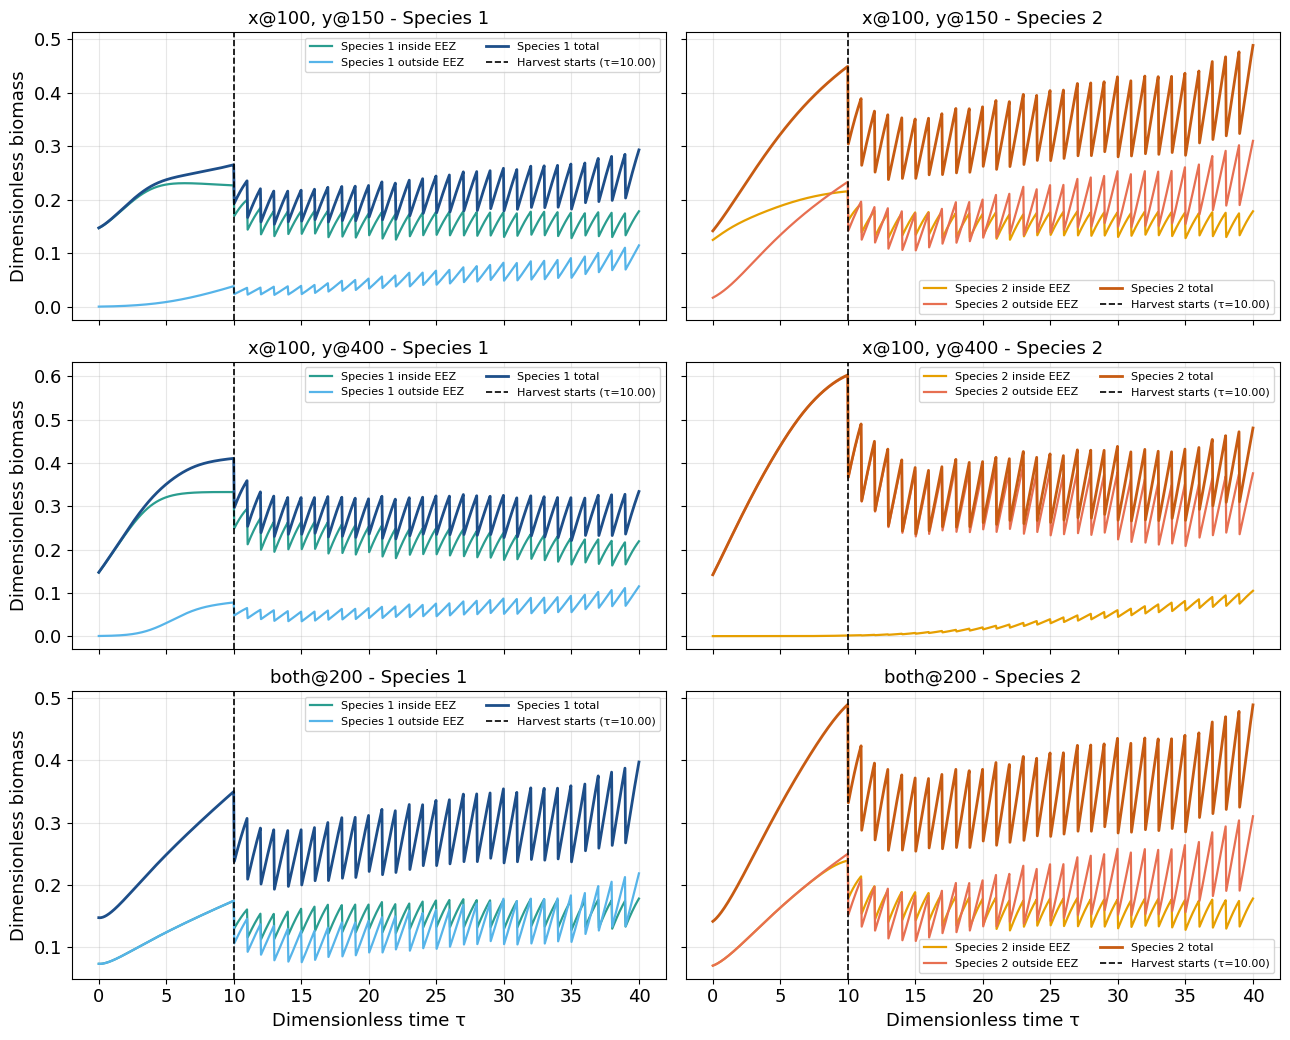

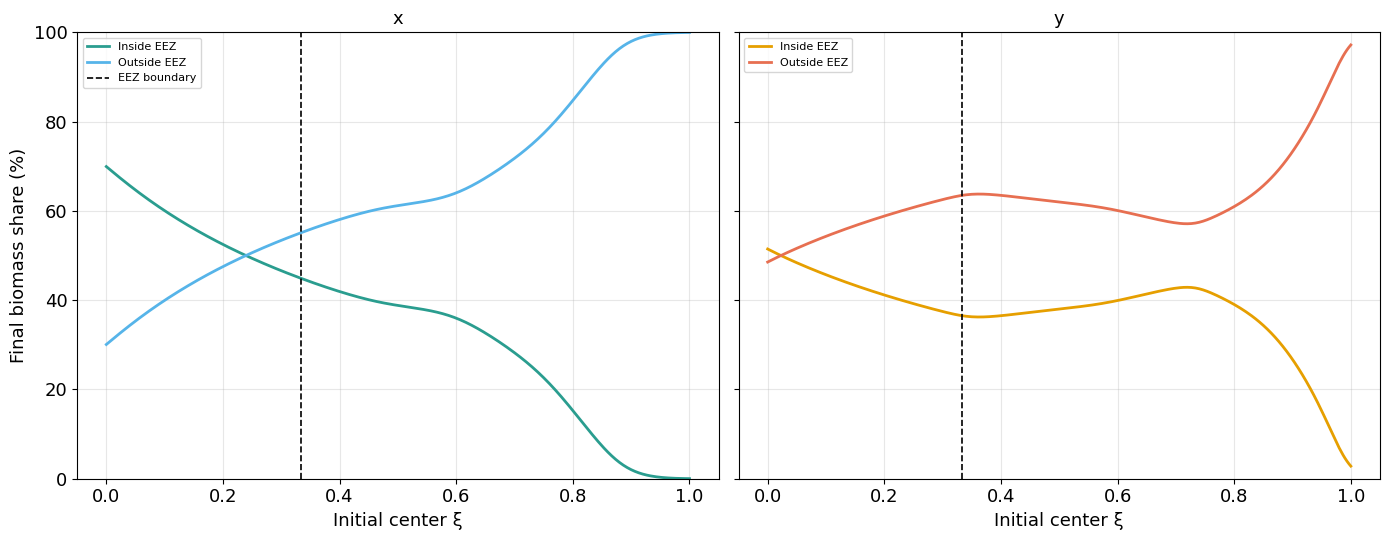

In [308]:
from matplotlib import pyplot as plt

res_Ciii = simulate_competing_rd_fishing(
    L=L_4c,
    N=N_4c,
    D1=D1_4c,
    D2=D2_4c,
    r1=r1_4c,
    r2=r2_4c,
    K1=K1_4c,
    K2=K2_4c,
    alpha=alpha_4c,
    beta=beta_4c,
    T_end=T_total_4c,
    s_boundary=S_BND_4c,
    h1_in=h_MEY_4c.mean(),
    h1_out=h_MSY_4c.mean(),
    h2_in=h_MEY_4c.mean(),
    h2_out=h_MSY_4c.mean(),
    h1_in_schedule=h_MEY_4c,
    h1_out_schedule=h_MSY_4c,
    h2_in_schedule=h_MEY_4c,
    h2_out_schedule=h_MSY_4c,
    u0_gaussian_center=200.0,
    u0_gaussian_scale=50.0,
    v0_gaussian_center=200.0,
    v0_gaussian_scale=60.0,
    snapshot_times=snapshot_times_4c,
    store_full=True,
    full_n_frames=full_frames_4c,
    harvest_start_time=warmup_4c,
)
res_Ciii_nd = to_nd_2s(res_Ciii, L_4c, r1_4c, K1_4c, K2_4c)
tag_Ciii = "4C(iii) Scenario C: both species at s=200 (on boundary)"
print(
    f"4C(iii) min_u={res_Ciii['min_u']:.3e}, min_v={res_Ciii['min_v']:.3e}; "
    f"harvest starts at t={warmup_4c:.2f} years"
)

plot_snapshots_2s(res_Ciii_nd, tag_Ciii, K1=K1_4c, K2=K2_4c)
plot_biomass_2s(res_Ciii_nd, tag_Ciii)
plot_catch_2s(res_Ciii_nd, tag_Ciii)
plot_heatmap_2s(res_Ciii_nd, tag_Ciii)
plt.show()

cases = [
    (results_4c_nd["C"], "C(i): u@100, v@150"),
    (res_Cii_nd, "C(ii): u@100, v@400"),
    (res_Ciii_nd, "C(iii): both@200"),
]
plot_biomass_comparison_2s(cases)
plt.show()

scen_pct_4c = SCENARIOS_4C["C"]
shared_start_positions_4c = np.asarray(results_4c["C"]["s"], dtype=float)
x_in_pct_sweep_4c = []
x_out_pct_sweep_4c = []
y_in_pct_sweep_4c = []
y_out_pct_sweep_4c = []

for start_pos in shared_start_positions_4c:
    sweep_res_4c = simulate_competing_rd_fishing(
        L=L_4c,
        N=N_4c,
        D1=D1_4c,
        D2=D2_4c,
        r1=r1_4c,
        r2=r2_4c,
        K1=K1_4c,
        K2=K2_4c,
        alpha=alpha_4c,
        beta=beta_4c,
        T_end=T_total_4c,
        s_boundary=S_BND_4c,
        h1_in=scen_pct_4c["h1_in"],
        h1_out=scen_pct_4c["h1_out"],
        h2_in=scen_pct_4c["h2_in"],
        h2_out=scen_pct_4c["h2_out"],
        h1_in_schedule=scen_pct_4c["h1_in_schedule"],
        h1_out_schedule=scen_pct_4c["h1_out_schedule"],
        h2_in_schedule=scen_pct_4c["h2_in_schedule"],
        h2_out_schedule=scen_pct_4c["h2_out_schedule"],
        u0_gaussian_center=float(start_pos),
        u0_gaussian_scale=50.0,
        v0_gaussian_center=float(start_pos),
        v0_gaussian_scale=60.0,
        snapshot_times=[],
        harvest_start_time=warmup_4c,
    )
    b1_tot_final = float(sweep_res_4c["B1_tot"][-1])
    b2_tot_final = float(sweep_res_4c["B2_tot"][-1])
    x_in_pct_sweep_4c.append(0.0 if np.isclose(b1_tot_final, 0.0) else 100.0 * float(sweep_res_4c["B1_in"][-1]) / b1_tot_final)
    x_out_pct_sweep_4c.append(0.0 if np.isclose(b1_tot_final, 0.0) else 100.0 * float(sweep_res_4c["B1_out"][-1]) / b1_tot_final)
    y_in_pct_sweep_4c.append(0.0 if np.isclose(b2_tot_final, 0.0) else 100.0 * float(sweep_res_4c["B2_in"][-1]) / b2_tot_final)
    y_out_pct_sweep_4c.append(0.0 if np.isclose(b2_tot_final, 0.0) else 100.0 * float(sweep_res_4c["B2_out"][-1]) / b2_tot_final)

plotting.plot_biomass_2s_eez_percentages_by_start_position(
    shared_start_positions_4c / L_4c,
    np.asarray(x_in_pct_sweep_4c),
    np.asarray(x_out_pct_sweep_4c),
    np.asarray(y_in_pct_sweep_4c),
    np.asarray(y_out_pct_sweep_4c),
    eez_boundary=xi_bnd_4c,
    x_label="Initial center \u03be",
)
plt.show()
